In [1]:
import sys, os
os.chdir(os.path.abspath('..'))
sys.path.insert(0, os.getcwd())

# Inhomogeneous composition gas giant evolution tutorial

## Homogeneous profiles with compact cores

The simplest and technically inhomogeneous models you can do is to insert a compact core of mass `[core].mass_core` in your config file. Let's modify `parameter_examples/parameter_user.ini` and give it a compact core mass of 10 M$_\oplus$. You can choose whether to make this core isothermal by passing `isothermal_compact_core = True` or `False`. Let's make the core adiabatic instead of isothermal, which is the default option when `isothermal_compact_core = False`. 

Let's use `age_plot()` (see `tutorial_model_plotting.ipynb`) to explore how the two models differ.

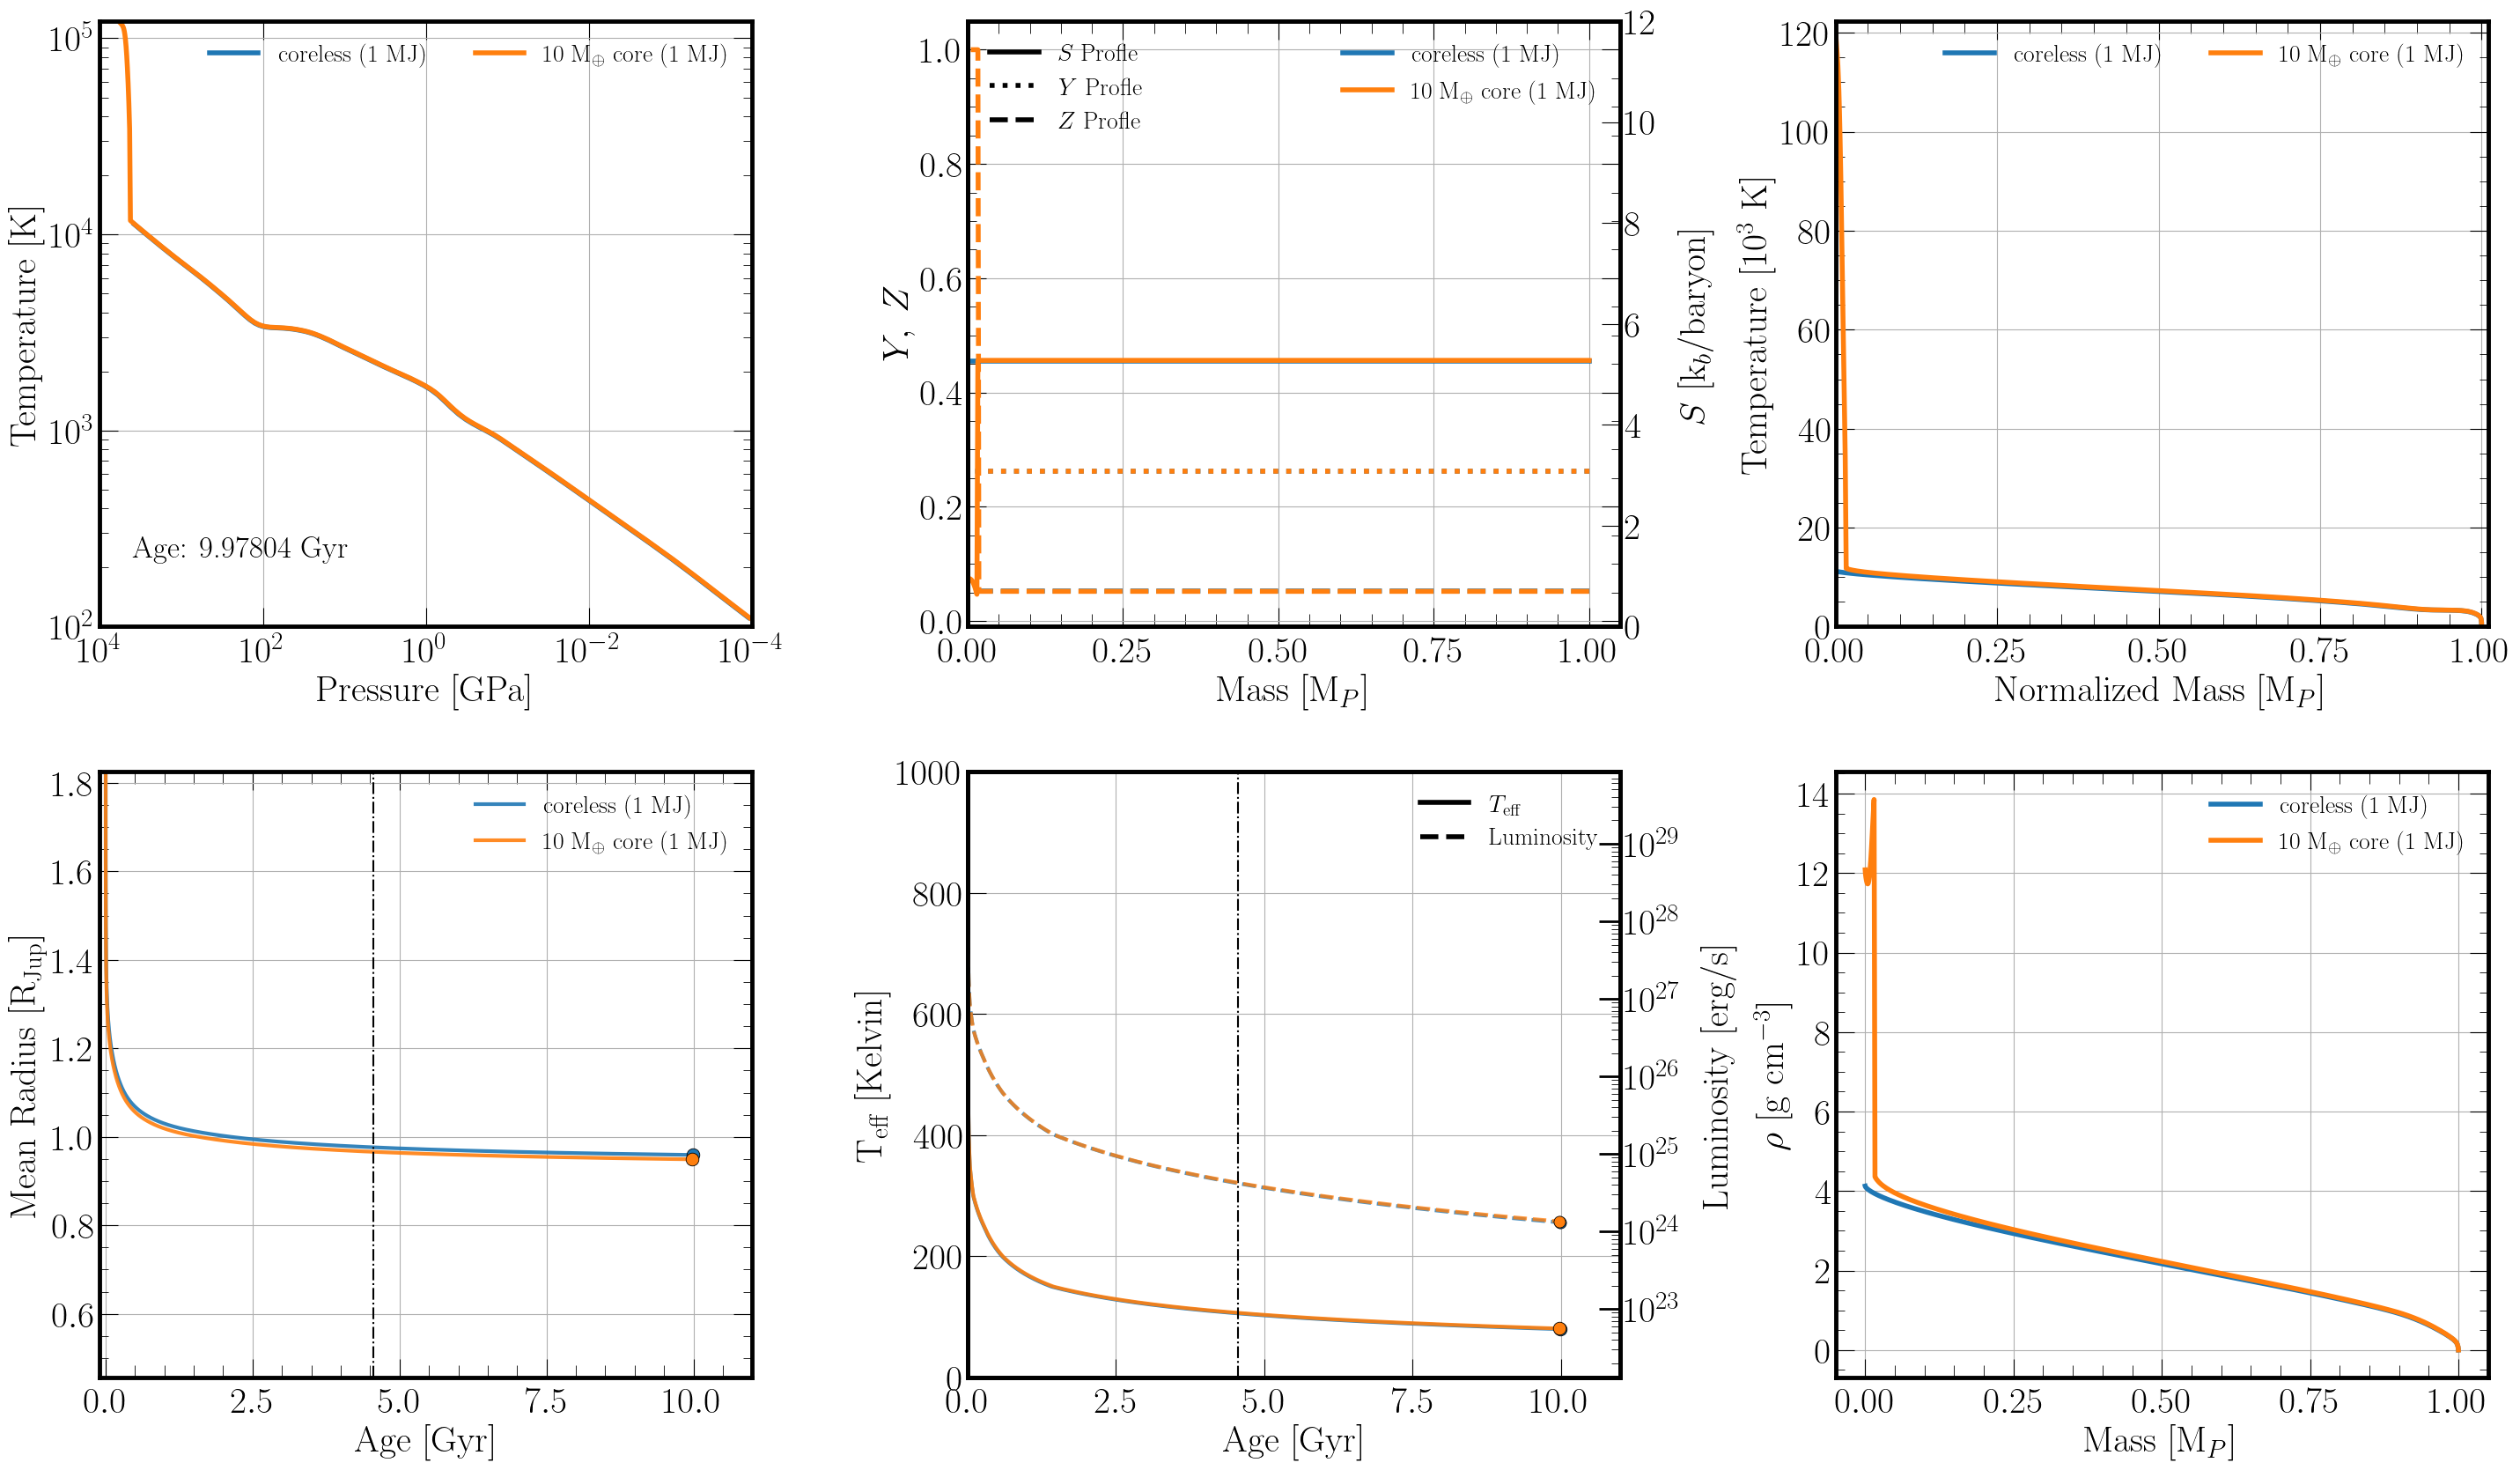

In [2]:
import plot_class

paths = [
    'parameter_examples/parameter_user.ini',
    'parameter_examples/parameter_user_core.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'coreless (1 MJ)',
    r'10 M$_\oplus$ core (1 MJ)',
]

init.still_plot(-1, # input time to plot profiles (in Gyr)
                'test',
                labels=labels,
                leg_size=20, # optional legend font size,
                panel_num=6,
        )

As you can see, the models are pretty similar. The model with a compact core has a slightly smaller overall radius. Contraction throughout the evolution raises the pressure at the core, transferring luminosity to the core, and heating it up. You can adjust the core conductivities from the default `mantle_thermal_conductivity = 100` (in W/m/K units). You can also change the core composition from `mg2sio4` to `mgsio3`, or to a water-based core (`mantle_comp = h2o` for a pure AQUA water core, or `mantle_comp = aquarock` for a water-rock mixture). 

**WARNING**: The MgSiO3 and Mg2SiO4 rock EOSes are designed for super-Earth and sub-Neptune mantle interiors up to just a few TPa and around 30,000 K. As such, these are quite obscene extrapolations we're asking the code to do. Feel free to provide and use your own EOS in the core should you have a more stable version. Due to this, not all core masses and iron core mass (`mass_core_fe`) fractions will converge. If you'd like more freedom to explore, feel free to use the aqua core version. 

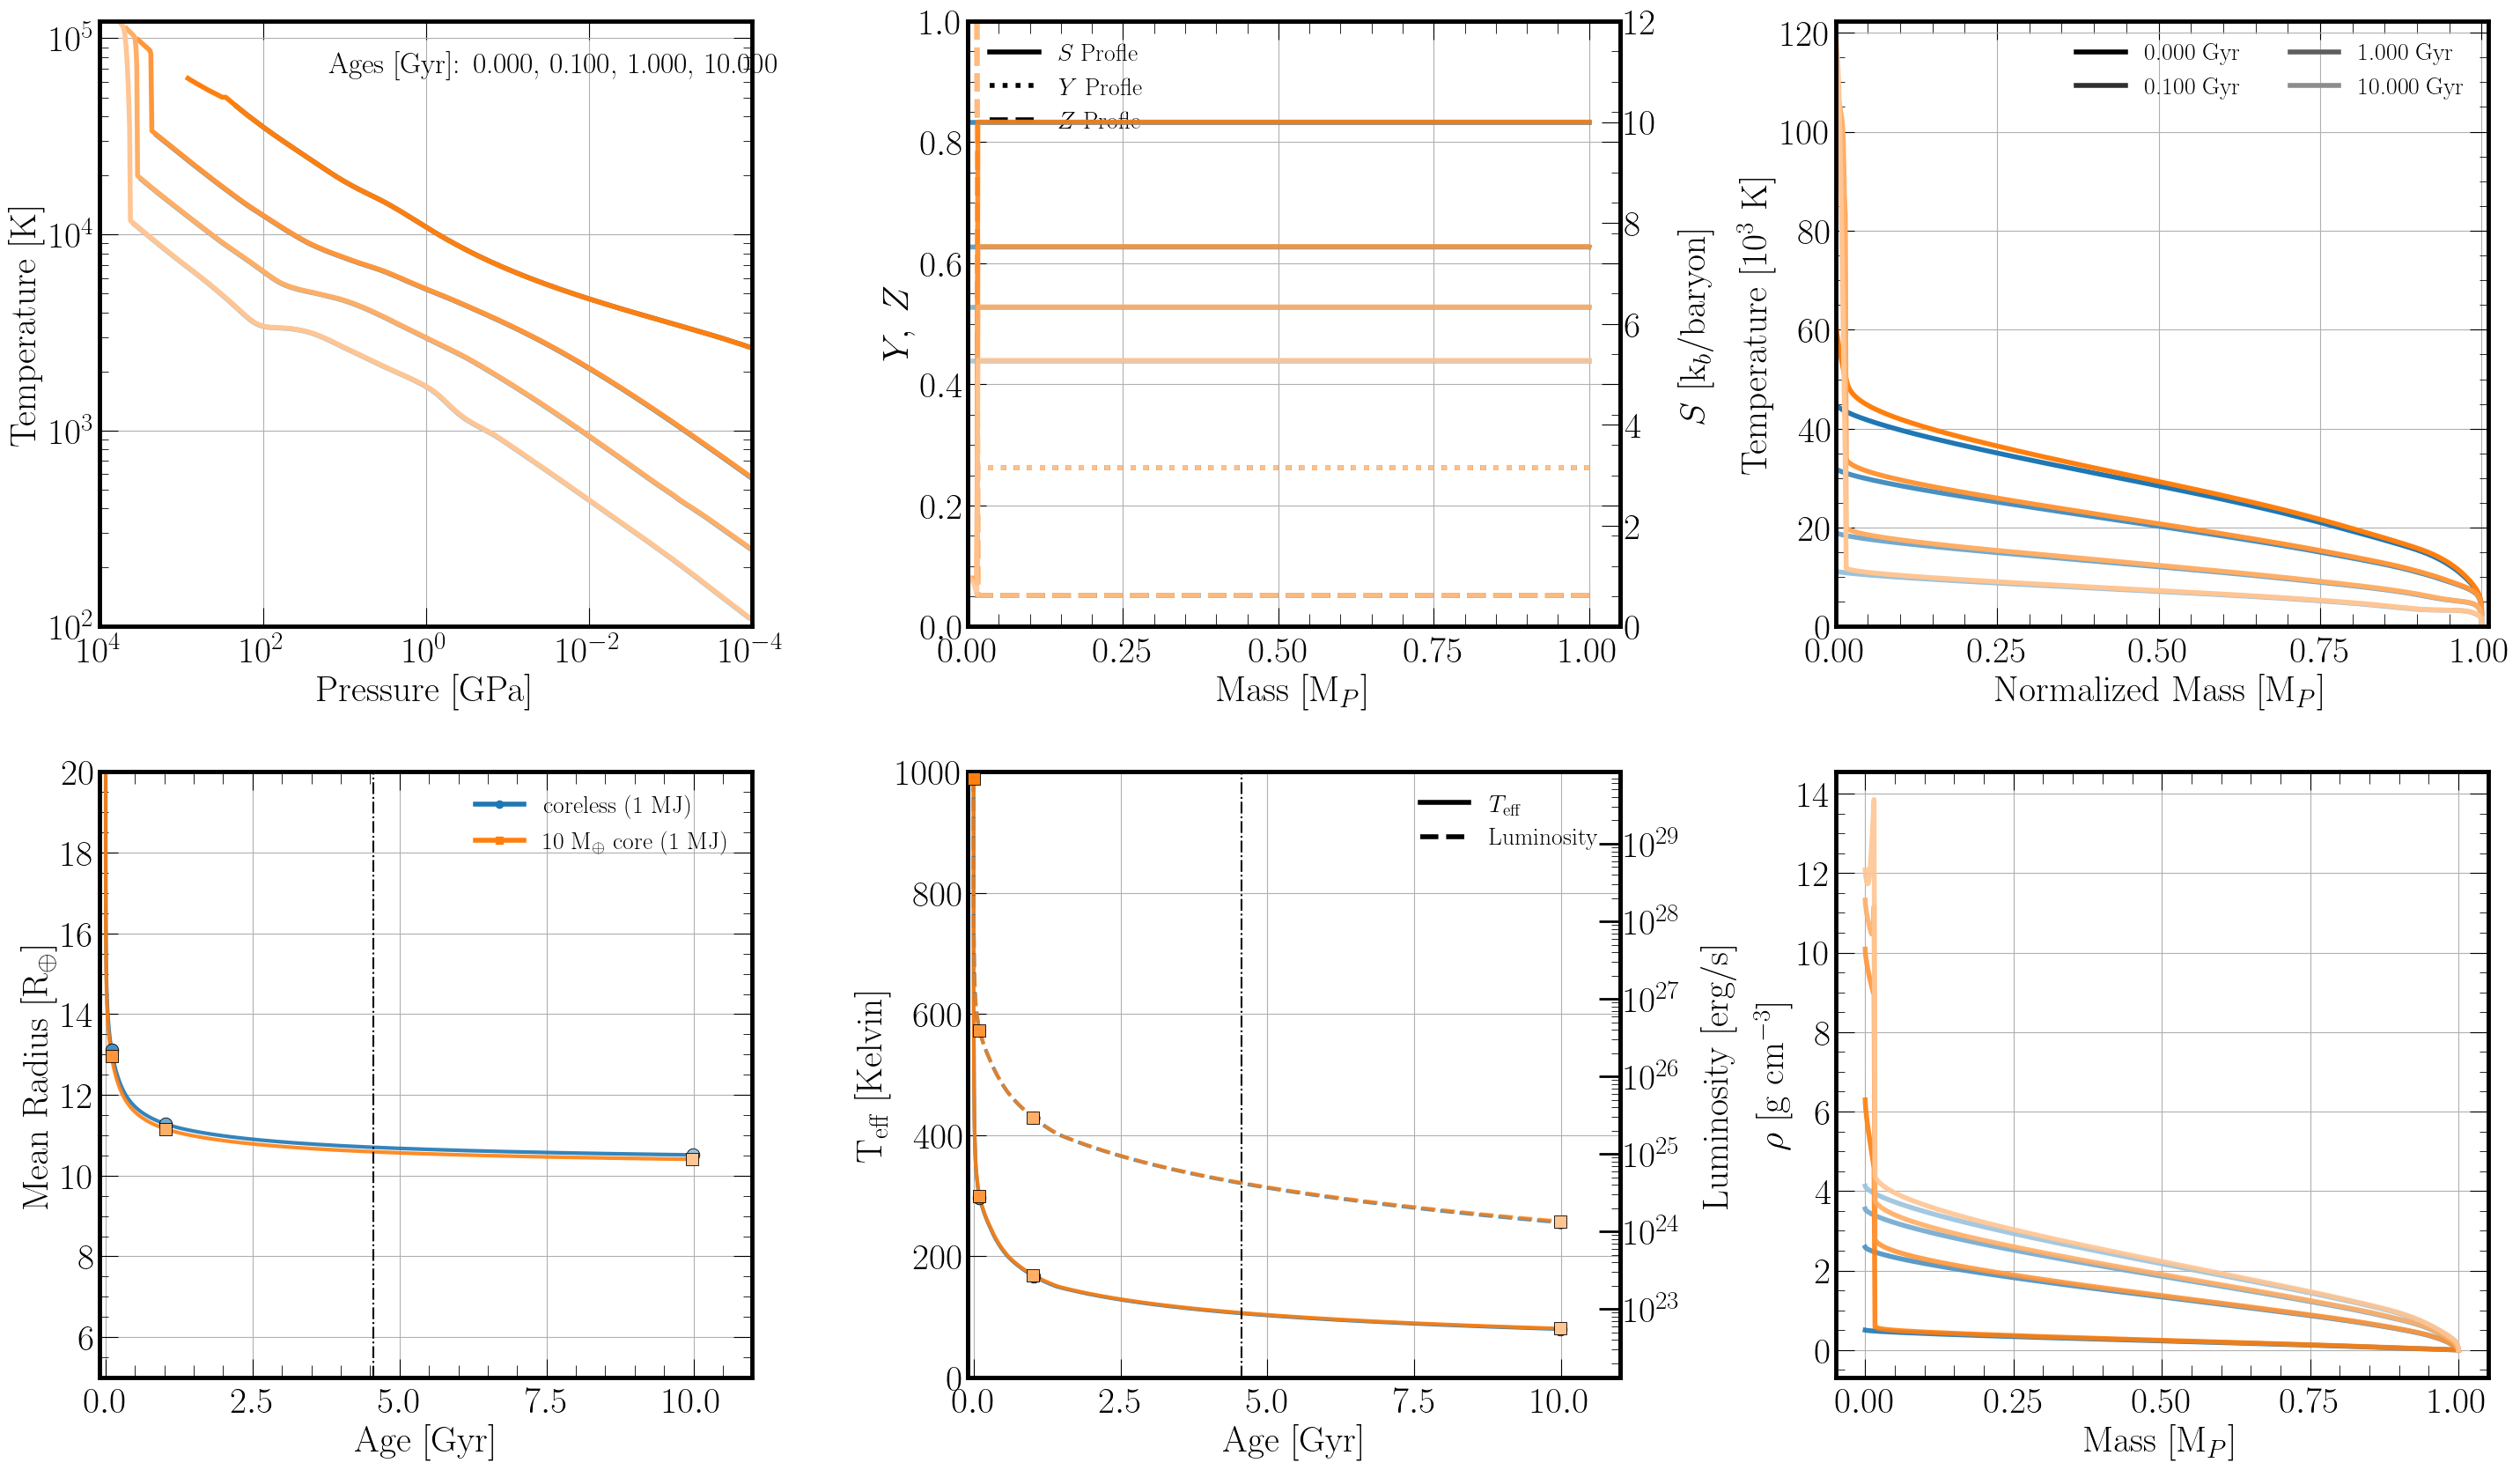

In [3]:
import plot_class

paths = [
    'parameter_examples/parameter_user.ini',
    'parameter_examples/parameter_user_core.ini'
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'coreless (1 MJ)',
    r'10 M$_\oplus$ core (1 MJ)',
]

init.age_plot(
    ages=[0, 0.1, 1.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
)

# Models with Helium rain

To allow your model to undergo helium rain, you may simply turn on the helium rain flag: `helium_rain = True`. Then you can choose your miscibility curve, `misc_curve = l` or `misc_curve = s`. The markers `l` or `s` indicate either Lorenzen et al. (2009, 2011) or Schoettler et al. (2018). More miscibility curves will be added in the future.

Since the temperature offset to the miscibility curves is a common free parameter in gas giant planet evolution modeling, you can choose the delta temperature offset with `misc_deltaT`. Physically, `misc_deltaT` shifts the entire Y vs. (P,T) miscibility surface in temperature, a larger offset delays helium-rain onset and changes where in the planet rain begins. The example file [`parameter_user_jup_herain.ini`](../parameter_examples/parameter_user_jup_herain.ini) uses `misc_deltaT = 410`, close to what we found in Tejada Arevalo et al. (2025) and Sur et al. (2025).

In this section, we compare two identical Jupiter models using our irradiated and cloudy Jupiter boundary conditions (Chen et al. 2023), since helium rain is usually applied to Jupiter and Saturn evolution models. From `parameter_user.ini`, we change `bc_atm = c23`, and use `irradiation = True` and `cloud = True`.

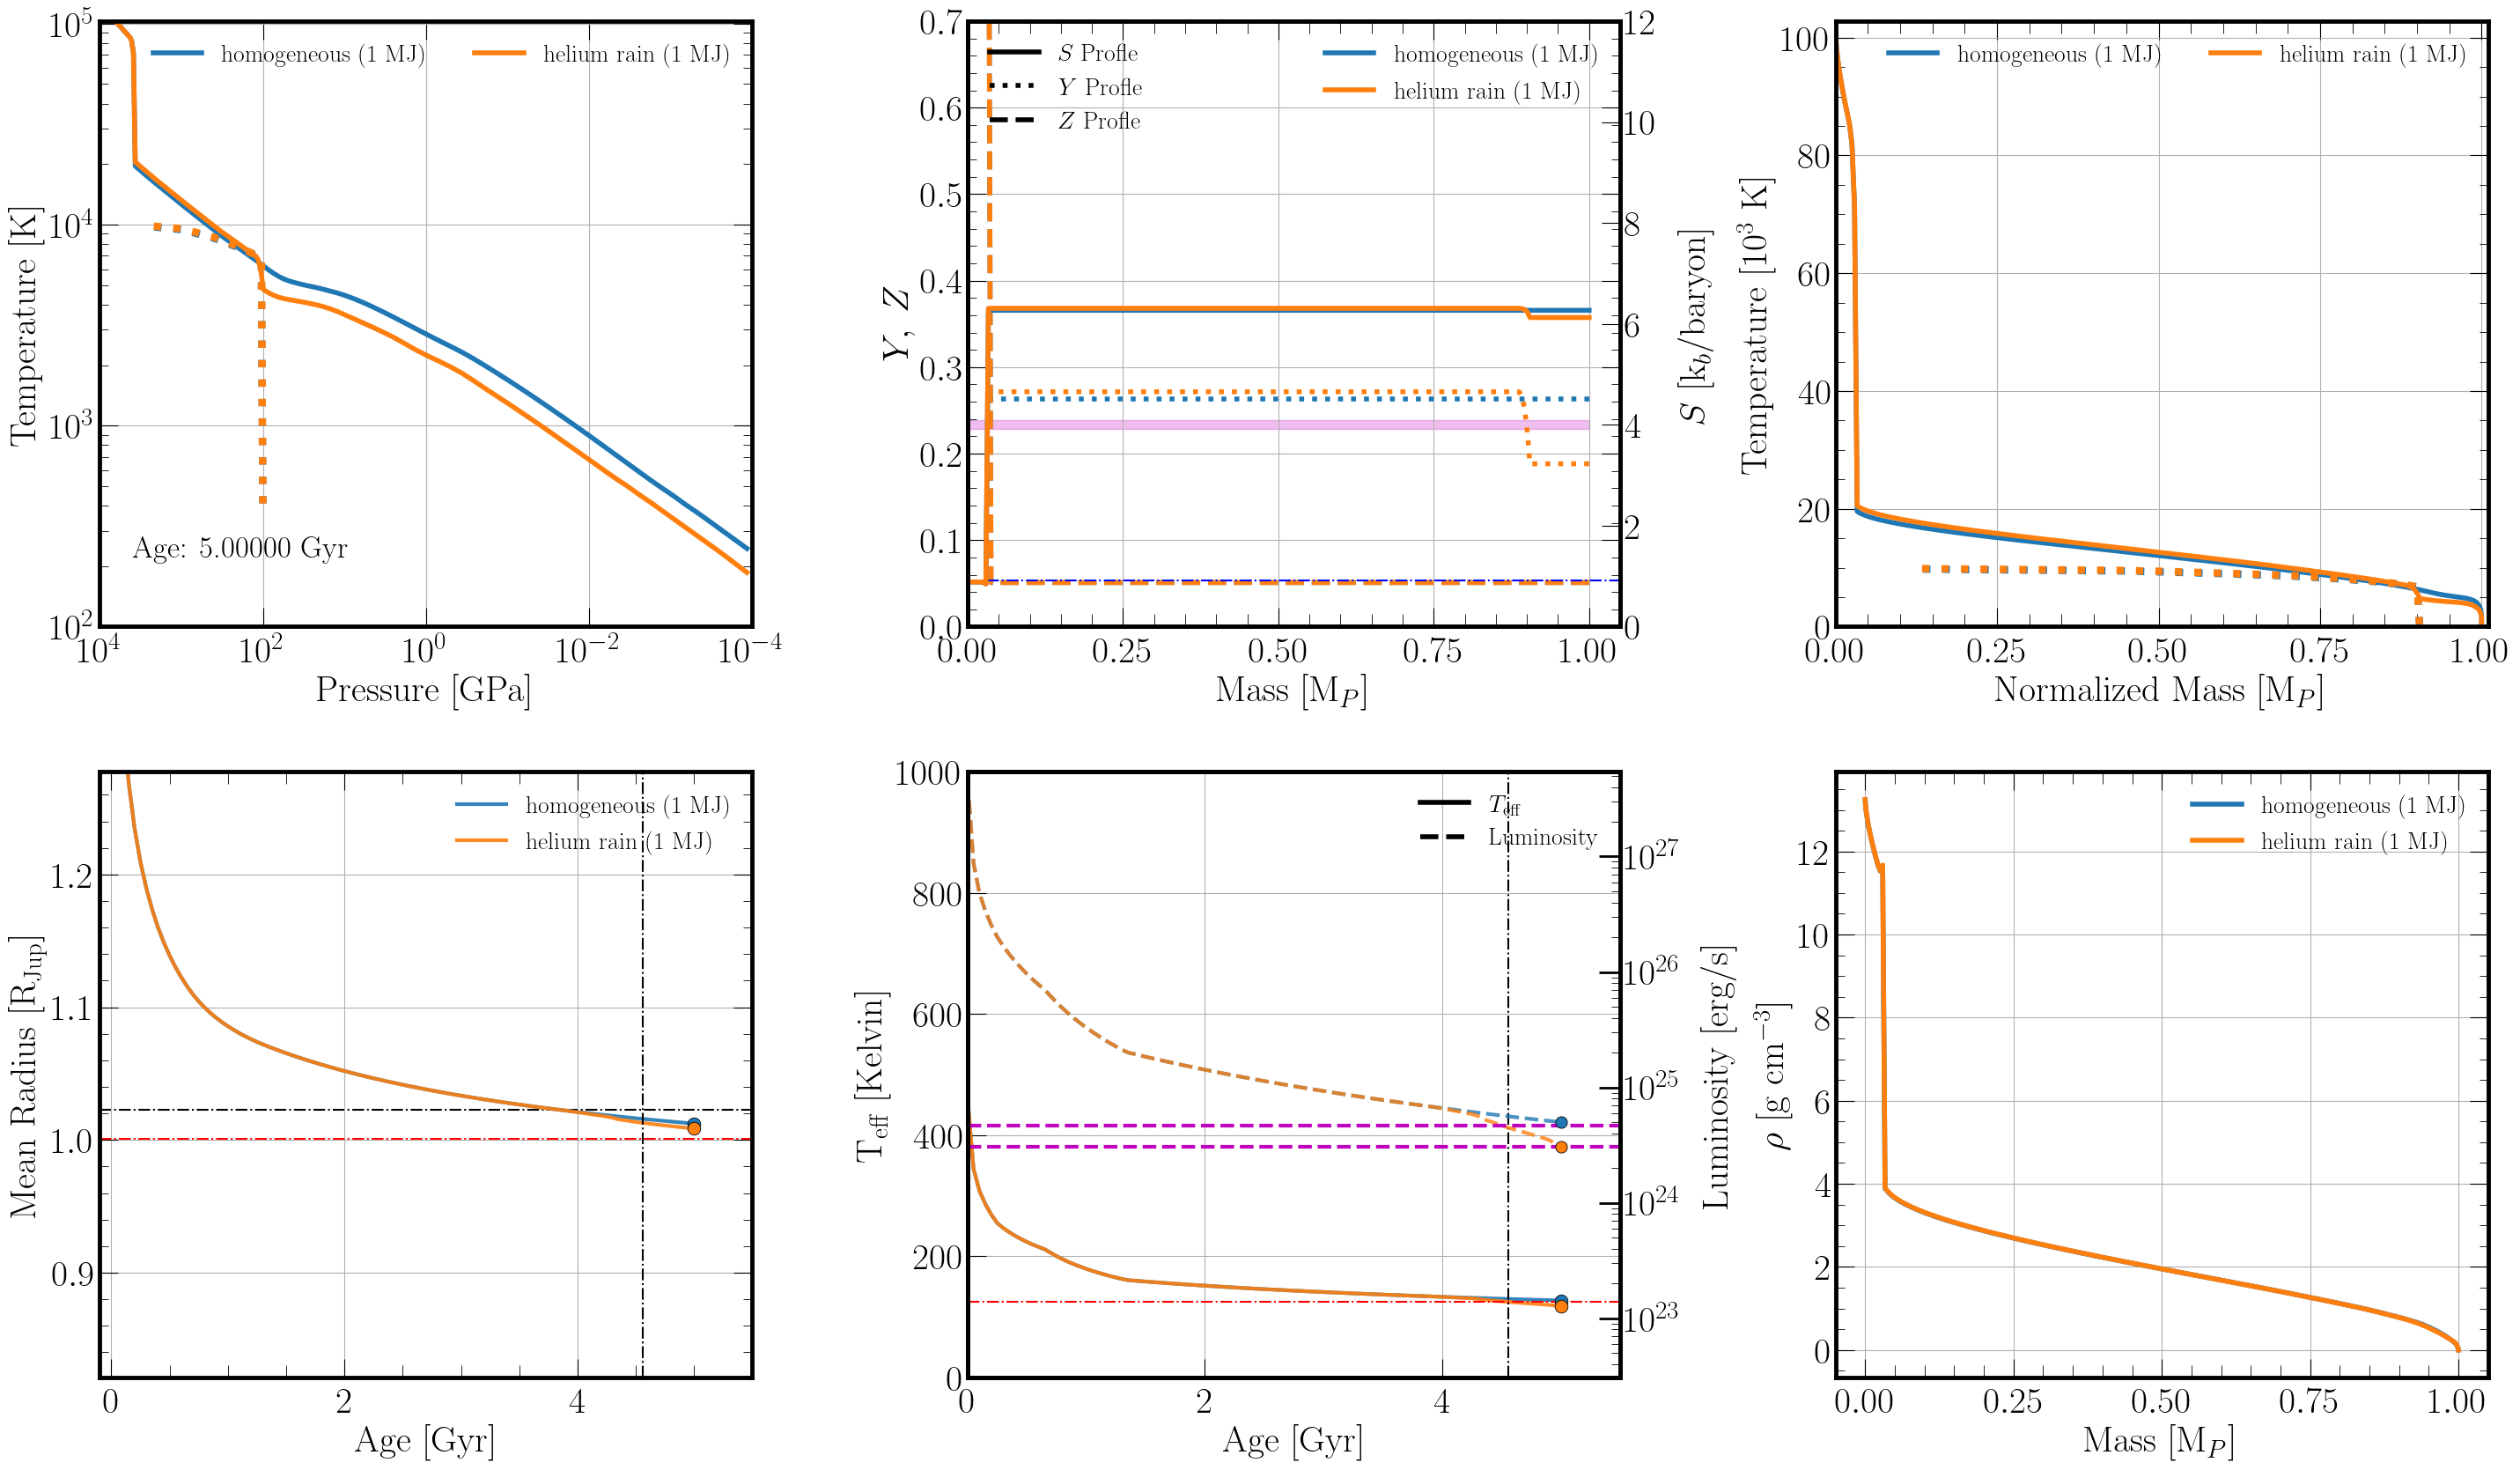

In [4]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_noherain.ini',
    'parameter_examples/parameter_user_jup_herain.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'homogeneous (1 MJ)',
    r'helium rain (1 MJ)',
]

init.still_plot(-1, # input time to plot profiles (in Gyr)
                'test',
                labels=labels,
                leg_size=20, # optional legend font size,
                panel_num=6,
                plot_he_rain = True, # when this is true, the T(P,Y) miscibility curve shows up in the temperature plots as a dotted line.
        )

There's not much difference until the helium rain model reaches the miscibility curve at around 4 Gyrs, upon which the effective temperature and luminosity begin to cool precipitously. This behavior is conventionally unexpected, but it's a result of the application of the Ledoux condition, or `R_rho=1.0` in these examples. Setting `R_rho = 0.0`, or anything closer to 0.0, will cause the outer regions to heat up, as expected (See Sur et al. (2025 b) for more on this). 

The miscibility curves adjust to the local $P,T$ coordinates and as such, the miscibility temperature and pressure area also time dependent. These are smoothed out in time using a parameter called `t_Db_relax`, in units of Myr. Usually 1 Myr is sufficient, but it's a parameter you can adjust should you need a more smooth evolution at the cost of slightly slower depletion. 

`plot_class.py` automatically detects `Jupiter` as a planet in your config and provides reference values for the atmospheric helium abundance and the metal abundance in the Y,Z plot, the mean and equatorial radii in the radius plot, and the effective temperature in the effective temperature plot.

If you'd like to see how the helium rain model changes over time, just call `age_plot()` again:

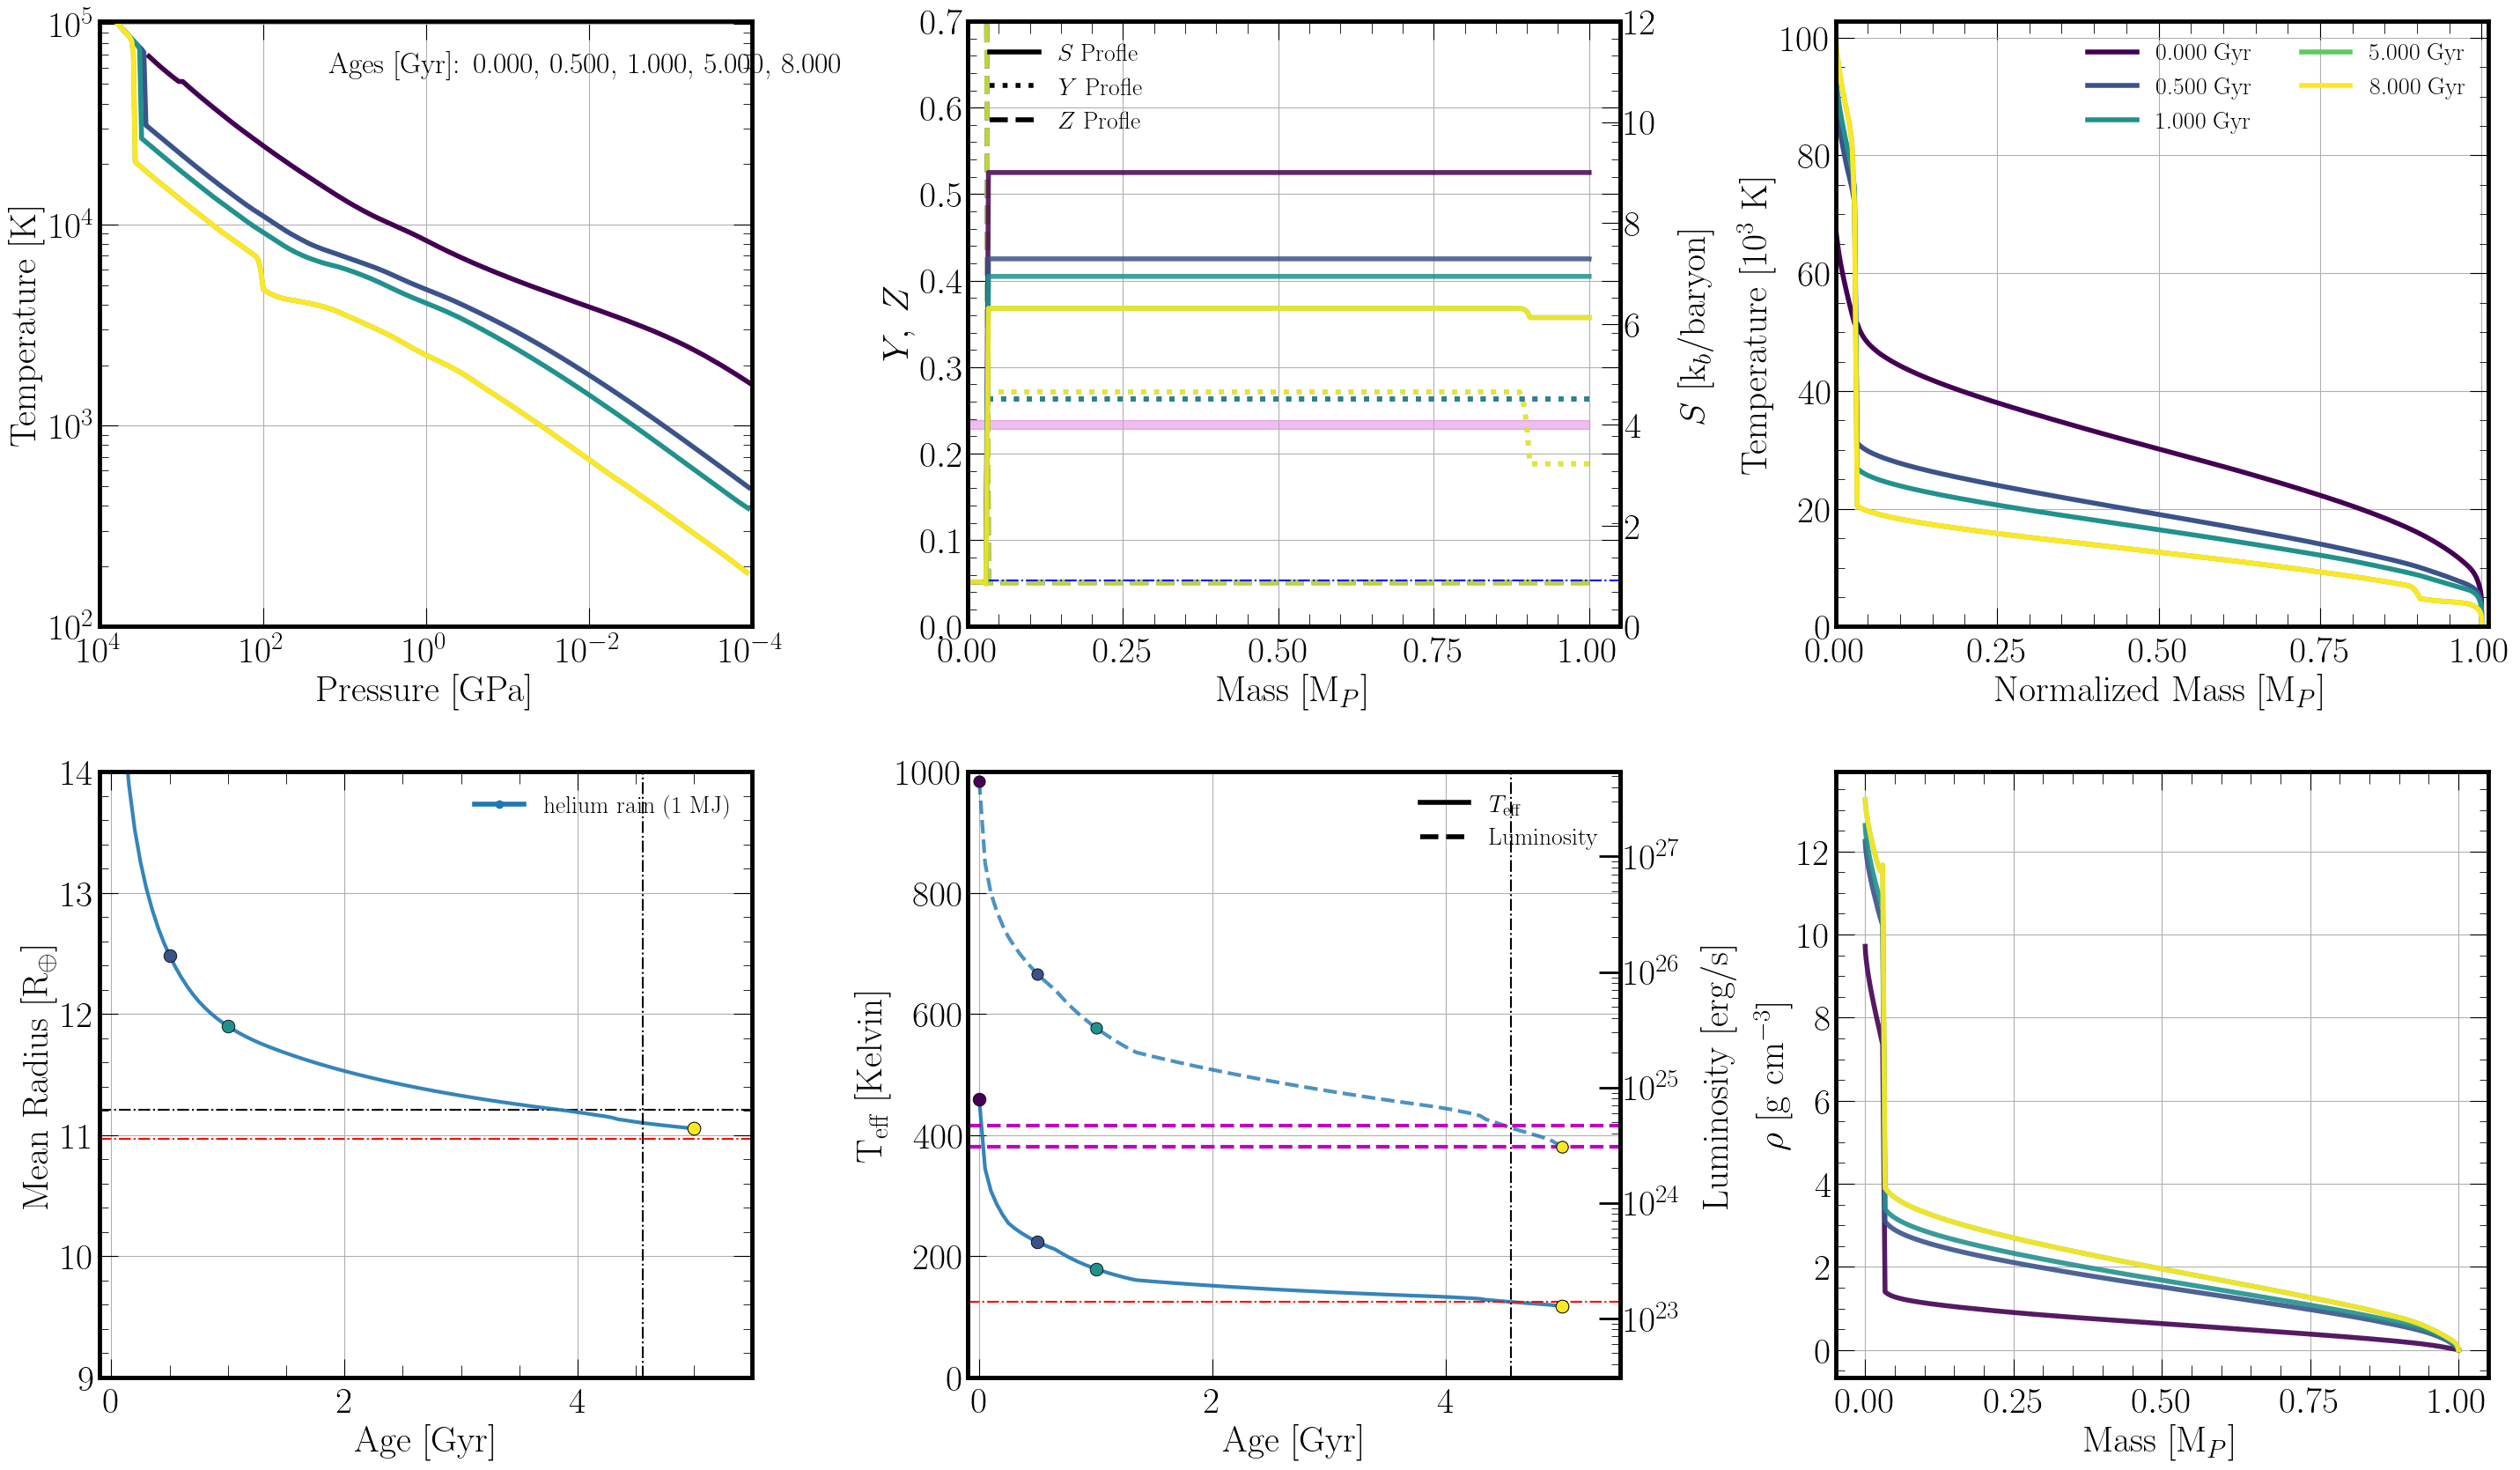

In [5]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_herain.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'helium rain (1 MJ)',
]

init.age_plot(
    ages=[0, 0.5, 1.0, 5.0, 8.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
    cmap='viridis'
)

# Inhomogeneous interior profiles

## Smart timestepping tips

Importantly, you can change the following parameters to control the saving intervals before a given age:

```
# Optional early-time save interval (Myr). If >0, saves at this finer cadence until early_save_until_gyr.
early_save_interval_myr = 0
# Age cutoff for the early-time save interval (Gyr). Used only if early_save_interval_myr > 0.
early_save_until_gyr = 0
# Save interval in Myr. Set to 0 to save every accepted step.
save_interval = 0

...

# Optional early-time cap on the adaptive timestep (Myr). Set >0 to enable.
early_max_step_myr = 0
# Age cutoff for the early-time timestep cap (Gyr). Used only if early_max_step_myr > 0.
early_max_step_until_gyr = 0
# Max step the model is allowed to take in Myr.
max_step = 20

```

If you notice that your inhomogeneous evolution slows, or if it is dumping too much data and the files are getting too large, there are other save interval options.
We may not want to save every age at early times because many of them are rejected and retried with small timesteps. If you set `early_save_until_gyr = 1.0`, then `early_save_interval_myr = 5`, then `save_interval = 50`, the model will dump data every 5 Myrs until it reaches an age of 1 Gyr, then dump every 50 Myrs after that.



## `struct` profiles

Setting up an inhomogeneous structure is explained in `parameters_default.ini` (in the repository root), but it deserves a fuller walkthrough because this is where most of the setup effort goes when you're modeling planets with stable regions.

The `struct` option for the S, Y, and Z profiles means you'll describe the profile as a set of breakpoints ("knots") in normalized mass space, with the profile constructed segment by segment between them. Two conventions to internalize first:

- Breakpoint coordinates (`*_init_coords`) run from 0 (the center) to 1 (the surface), listed in ascending order. By default these are fractions of the total mass (`mass_struct = True`). Set `mass_struct = False` if you'd rather place them in normalized radius.
- The profile is anchored at the surface by the uniform background values `S_ini`, `Y_ini`, and `Z_ini`. Any grid points outside the span of your breakpoints simply keep those background values.

There are two ways to tell `ORCHARD` what happens at the breakpoints. The first is deltas mode (`*_init_deltas`). You provide one delta per segment (so the deltas list is exactly one shorter than the coords list), and each delta is how much the quantity drops going inward across that segment. Positive deltas make the quantity fall toward the center (typical for $S$), and negative deltas make it rise (typical for $Z$). The deltas accumulate starting from the surface value. For example,

```
S_ini = 8.5
Y_ini = 0.277
Z_ini = 0.017

...

z_init_coords = [0, 0.2, 0.6, 1.0]
y_init_coords = []
s_init_coords = [0, 0.2, 0.6, 1.0]
z_init_deltas = [0, -0.25, 0]
y_init_deltas = []
s_init_deltas = [0, 1.7, 0]
```

Walking the entropy inward from the surface, the outermost segment ($M \in [0.6, 1.0]$) has delta 0, so $S = 8.5$ there. The middle segment drops by 1.7, so $S(M = 0.2) = 6.8$. The innermost segment has delta 0 again, so $S = 6.8$ all the way to the center. The $Z$ profile does the mirror image: $Z = 0.017$ outside $M = 0.6$, rising (negative delta) to $Z = 0.267$ at $M = 0.2$, and constant inside. Together these create a single stable region between normalized mass coordinates 0.2 and 0.6, a compositional gradient with its compensating entropy gradient.

An empty list (`y_init_coords = []` above) means "leave that quantity uniform." This simple one-stable-region example is exactly what's applied in [`parameter_examples/parameter_user_jup_inhomog_struct_example1.ini`](../parameter_examples/parameter_user_jup_inhomog_struct_example1.ini). Feel free to open it and compare against the numbers above.

**NOTE**: Deltas mode shines when you think of the stable region as "how big is the jump?", since you can vary a single delta to scan gradient strengths while `S_ini` keeps the surface pinned. Its weakness is that the interior values are consequences of the surface value and every delta outside them, so transcribing a specific target profile means doing arithmetic backwards from the surface. For that, use values mode below.

### Absolute values instead of deltas

The second way is values mode (`*_init_values`). Skip the deltas entirely and provide the absolute value of the quantity at each breakpoint (so the values list has the same length as the coords list). The deltas-mode example above, transcribed:

```
z_init_coords = [0, 0.2, 0.6, 1.0]
s_init_coords = [0, 0.2, 0.6, 1.0]
z_init_values = [0.267, 0.267, 0.017, 0.017]
s_init_values = [6.8, 6.8, 8.5, 8.5]
z_init_deltas = []
s_init_deltas = []
```

Same profile, stated directly. A few rules the code will hold you to (`initial.py` validates all of these at startup and refuses to run otherwise):

- For each quantity, provide either deltas or values, never both.
- `len(*_init_values) == len(*_init_coords)`, whereas `len(*_init_deltas) == len(*_init_coords) - 1`.
- Either way, `*_init_coords` is required.

**Tip for first-time users:** make the outermost value equal to the corresponding `*_ini` (here `s_init_values[-1] = 8.5 = S_ini`). The uniform background outside your breakpoint span is set by `*_ini`, so a mismatched outermost value would put a step discontinuity right where your profile meets the background. The Henyey solver will complain, and it will be right to.

### Interpolation and smoothing between breakpoints

By default the segments between breakpoints are straight lines (`struct_interp = linear`). Piecewise-linear profiles have kinks, and kinks in $S$ and $Z$ mean kinks in the Brunt-Väisälä frequency, which is usually harmless and occasionally annoying for the transport solver. You have two smoothing tools, and they compose.

`struct_interp = pchip` replaces the straight segments with monotone PCHIP cubics. The profile becomes smooth ($C^1$) while still passing exactly through your breakpoints, and, unlike a plain cubic spline, it will never overshoot between knots and hand you, say, a negative $Z$. This is the right choice when you have many knots tracing a curve, as in the Saturn example below.

`struct_smooth = True` applies a gaussian filter of width `struct_sigma` (in grid cells) over the whole profile. Higher sigma, softer profile. This rounds the corners of linear profiles. With `pchip` only this global smoothing is available (local edge smoothing is a linear-mode option internally, and PCHIP has no edges to round).

We'll see both in action below.

### Previewing profiles without running anything

Here's a trick worth knowing. The profile construction lives in `utils/profiles.py` in a class called `profile_builder`, and it needs nothing but arrays. No EOS, no config file, no evolution. So you can preview exactly what your breakpoints will produce in a couple of seconds, iterate until the profile looks right, and only then commit the numbers to your `.ini` file. This beats debugging an initial condition through a Henyey failure message every time.

The cell below builds our worked example in deltas mode and in values mode (they should overlay exactly, since it's the same profile), plus a `pchip` + smoothed variant:

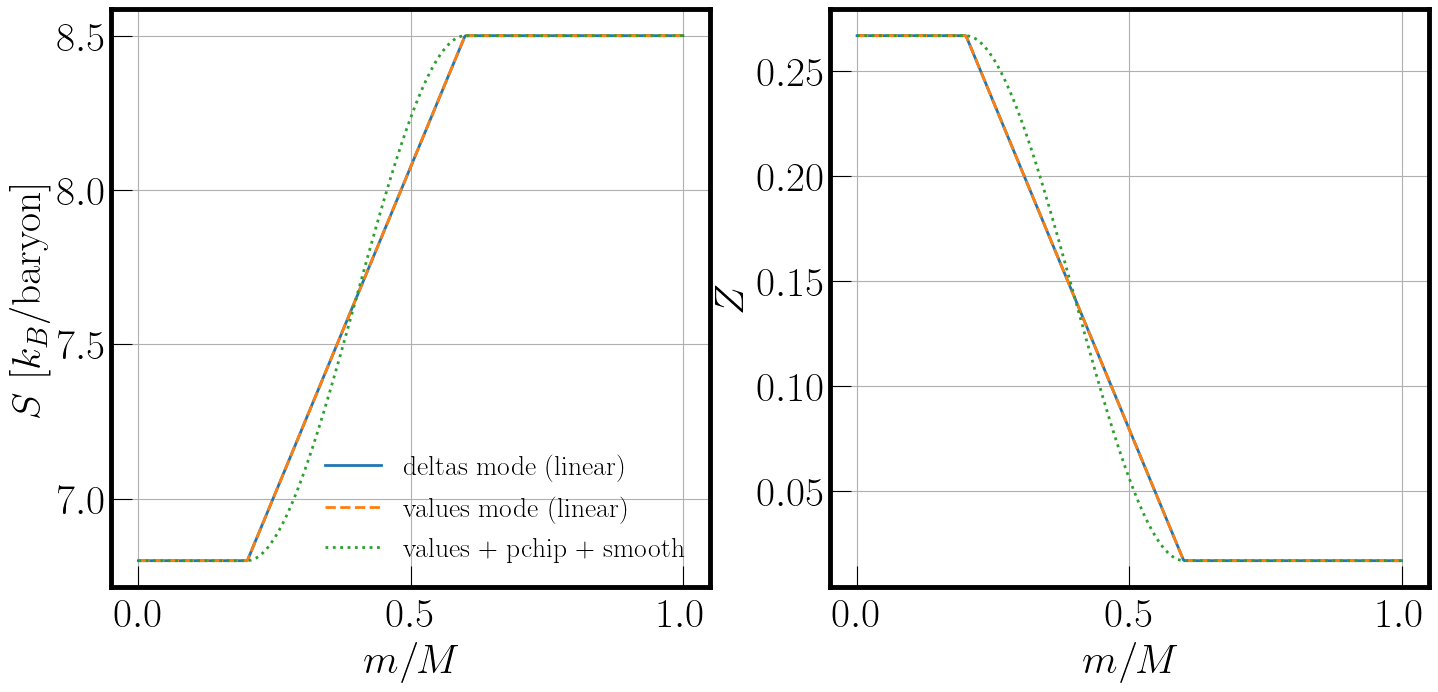

deltas vs values identical: True


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from utils.profiles import profile_builder

# A stand-in mass grid: surface (m/M = 1) at index 0, center at the end --
# the same outside->inside ordering ORCHARD uses internally.
N = 600
m_norm = np.linspace(1.0, 1e-6, N)
builder = profile_builder(np.linspace(1.0, 0.01, N), m_norm, 0.0, N)

S_ini, Z_ini = 8.5, 0.017
coords = [0, 0.2, 0.6, 1.0]

def fresh():
    return np.full(N, S_ini), np.zeros(N), np.full(N, Z_ini), np.zeros(N)

# Deltas mode: per-segment drops, accumulated inward from the surface values
S0, Y0, Z0, F0 = fresh()
S_d, _, Z_d, _ = builder.n_point_profile_mass(
    coords, [], coords, [],            # s/y/z/f_rock coords ([] = leave uniform)
    [0, 1.7, 0], [], [0, -0.25, 0], [],  # s/y/z/f_rock deltas
    S0, Y0, Z0, F0)

# Values mode: absolute values at each knot -- same profile, stated directly
S0, Y0, Z0, F0 = fresh()
S_v, _, Z_v, _ = builder.n_point_profile_mass(
    coords, [], coords, [],
    [], [], [], [],
    S0, Y0, Z0, F0,
    s_values=[6.8, 6.8, 8.5, 8.5], z_values=[0.267, 0.267, 0.017, 0.017])

# PCHIP interpolation + global gaussian smoothing on the same knots
S0, Y0, Z0, F0 = fresh()
S_p, _, Z_p, _ = builder.n_point_profile_mass(
    coords, [], coords, [],
    [], [], [], [],
    S0, Y0, Z0, F0,
    s_values=[6.8, 6.8, 8.5, 8.5], z_values=[0.267, 0.267, 0.017, 0.017],
    interp_method='pchip', smooth_method='global_gaussian', smooth_sigma=2.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7.5))
ax1.plot(m_norm, S_d, lw=2, label='deltas mode (linear)')
ax1.plot(m_norm, S_v, lw=2, ls='--', label='values mode (linear)')
ax1.plot(m_norm, S_p, lw=2, ls=':', label='values + pchip + smooth')
ax1.set_xlabel(r'$m/M$'); ax1.set_ylabel(r'$S$ [$k_B$/baryon]')
ax1.legend(frameon=False, prop={'size': 20})

ax2.plot(m_norm, Z_d, lw=2)
ax2.plot(m_norm, Z_v, lw=2, ls='--')
ax2.plot(m_norm, Z_p, lw=2, ls=':')
ax2.set_xlabel(r'$m/M$'); ax2.set_ylabel(r'$Z$')

plt.show()

print('deltas vs values identical:', np.allclose(S_d, S_v) and np.allclose(Z_d, Z_v))

The solid and dashed curves overlay exactly. Deltas and values are just two spellings of the same profile, and the dotted curve shows what `pchip` + smoothing does to the corners.

**NOTE**: This preview shows the profile shape logic. In a real run there are two additional wrinkles the builder alone doesn't capture. The envelope helium is handled as $Y' = Y/(1-Z)$ internally, and if you set `mz_struct = True` the $Z$ profile gets rescaled so the total heavy-element mass matches `M_z` (in Earth masses) instead of honoring your surface `Z_ini`. The breakpoint geometry is identical either way.

**WARNING**: If you run the `plot_class.py` code below while your config is running (as I'm doing here), there's a small chance that it will error because `evolution.py` was caught in the middle of dumping data. Just try to run this cell block again if that happens. If it happens again, then you're very unlucky.

Running inhomogeneous models may take several hours, and maybe even more than 12 hours if rotation and moment of inertia corrections are included.

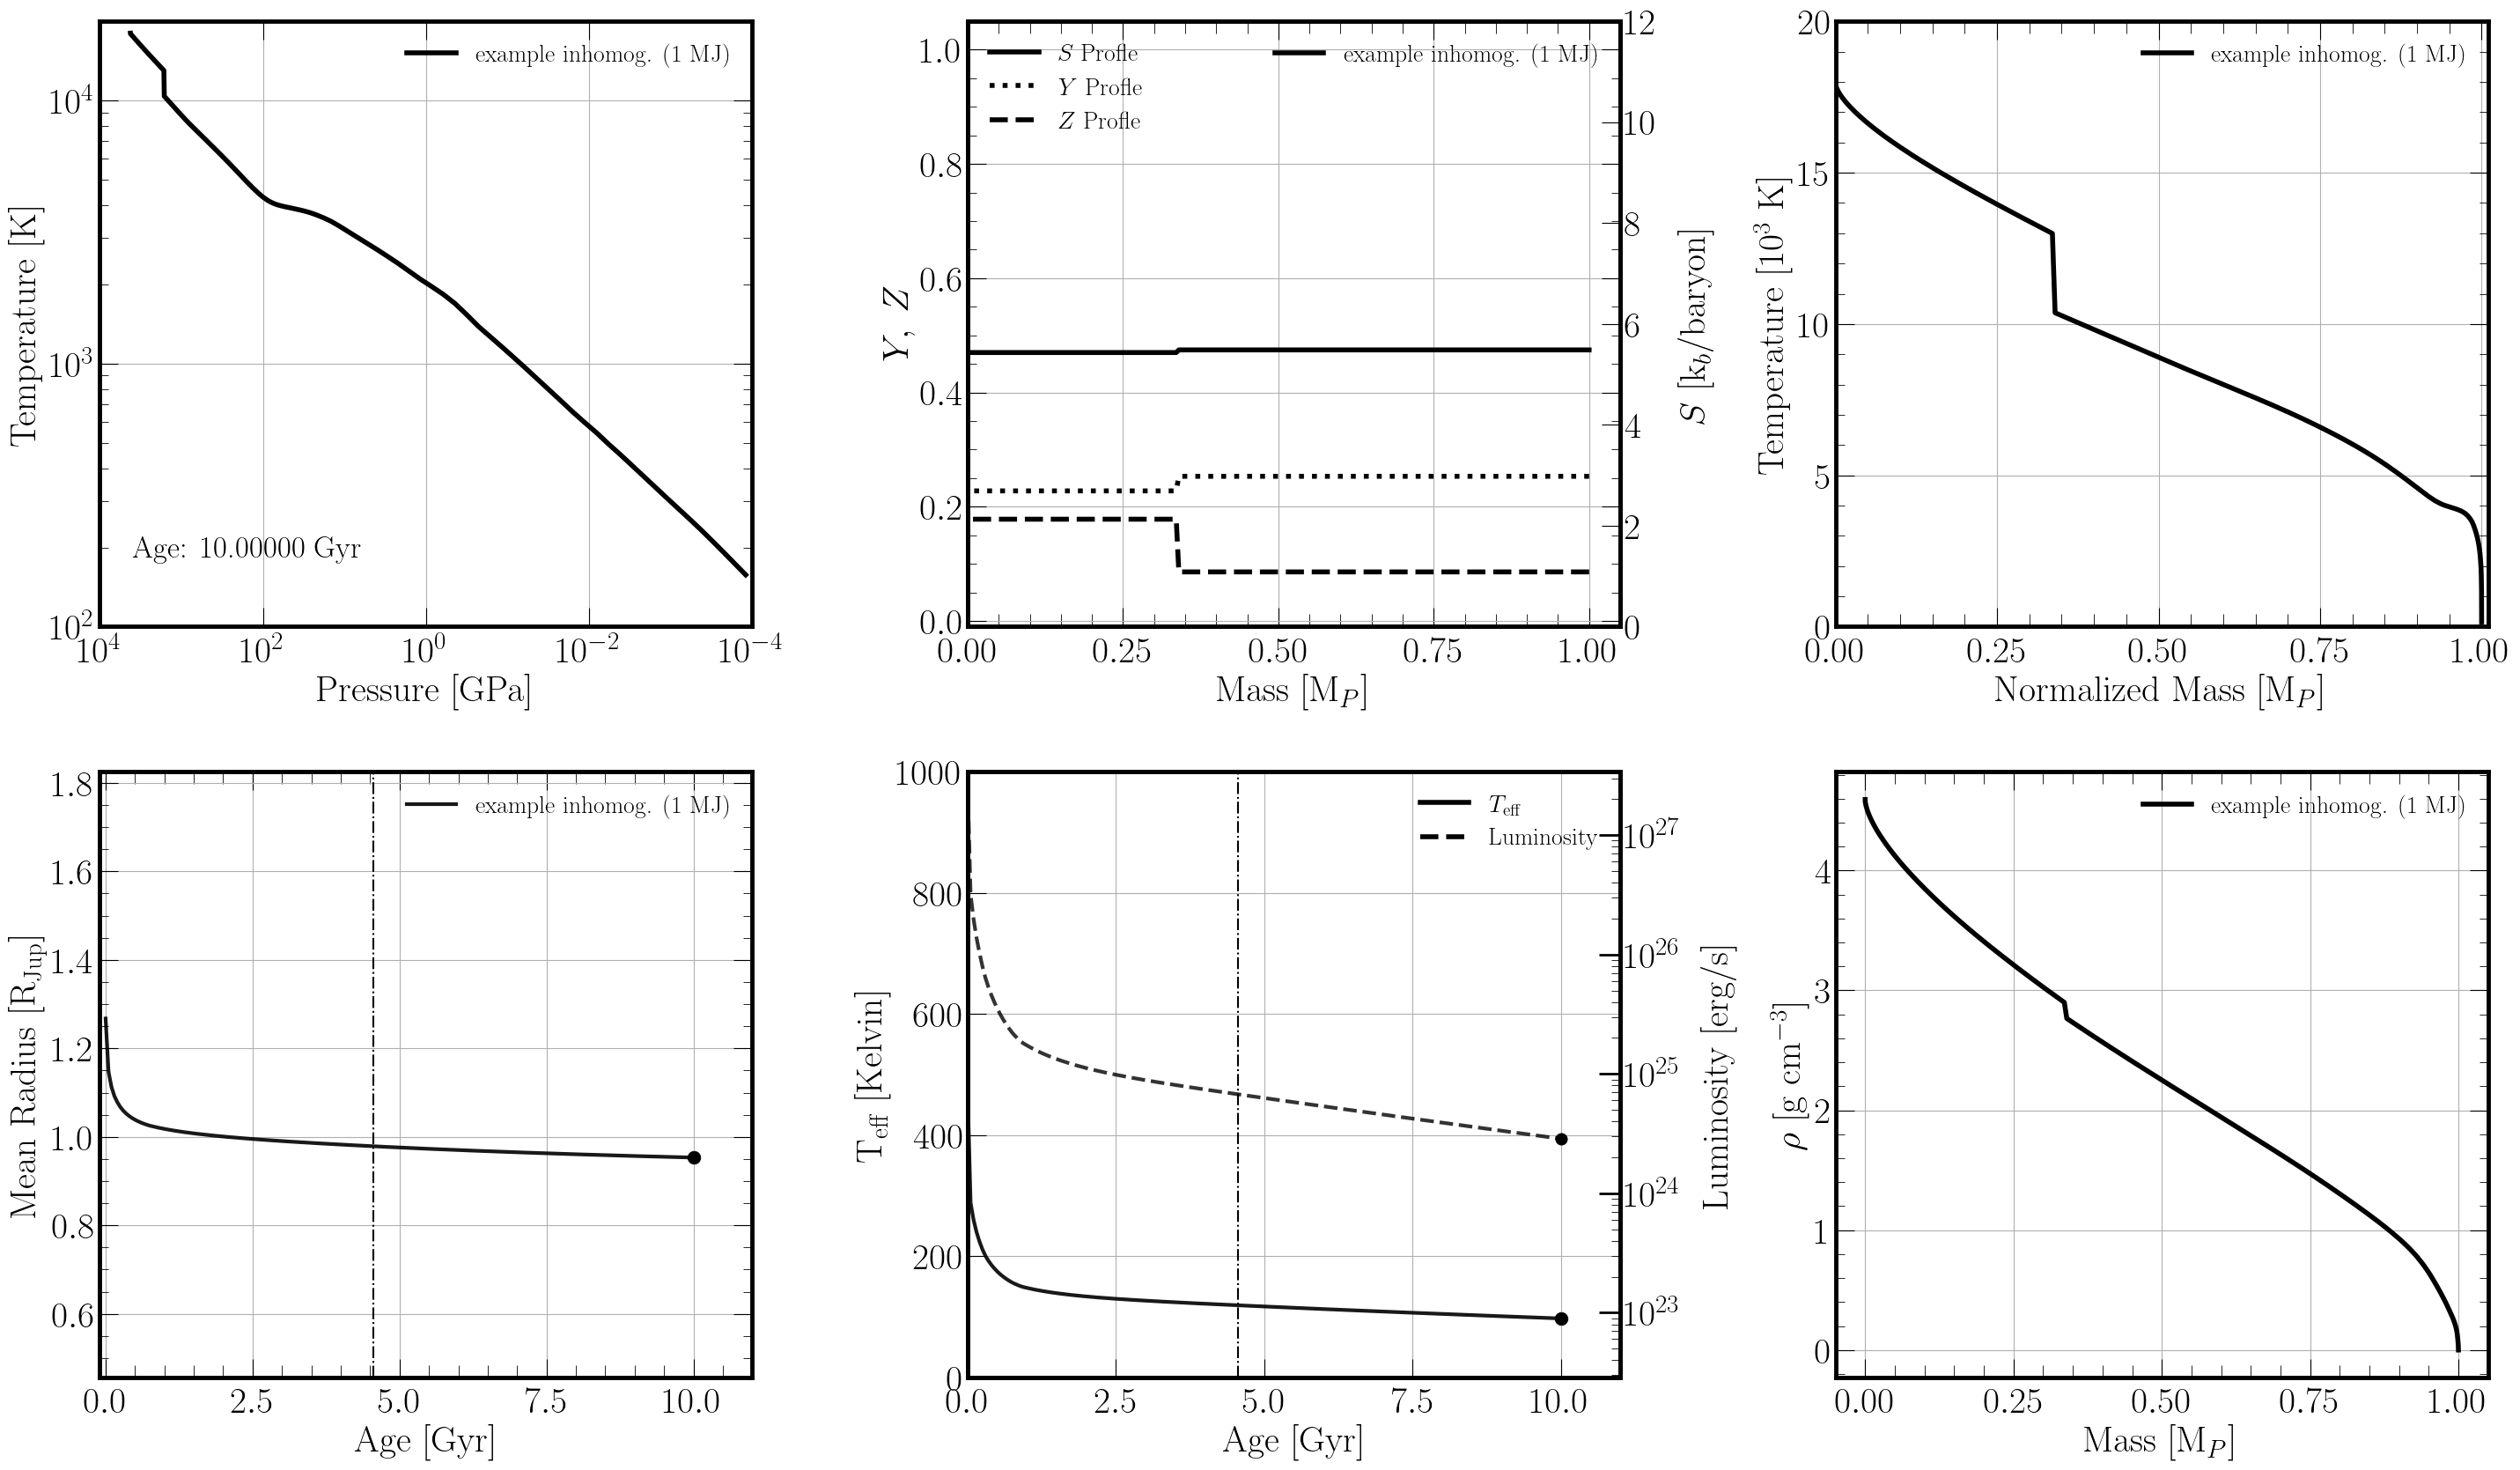

In [7]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_inhomog_struct_example1.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example inhomog. (1 MJ)',
]

init.still_plot(-1, # input time to plot profiles (in Gyr; -1 for final timestep)
                'test',
                labels=labels,
                leg_size=20, # optional legend font size,
                panel_num=6,
        )

If you'd like to compare the initial configuration to your current one while the evolution is still running, you can do so with `age_plot()`:

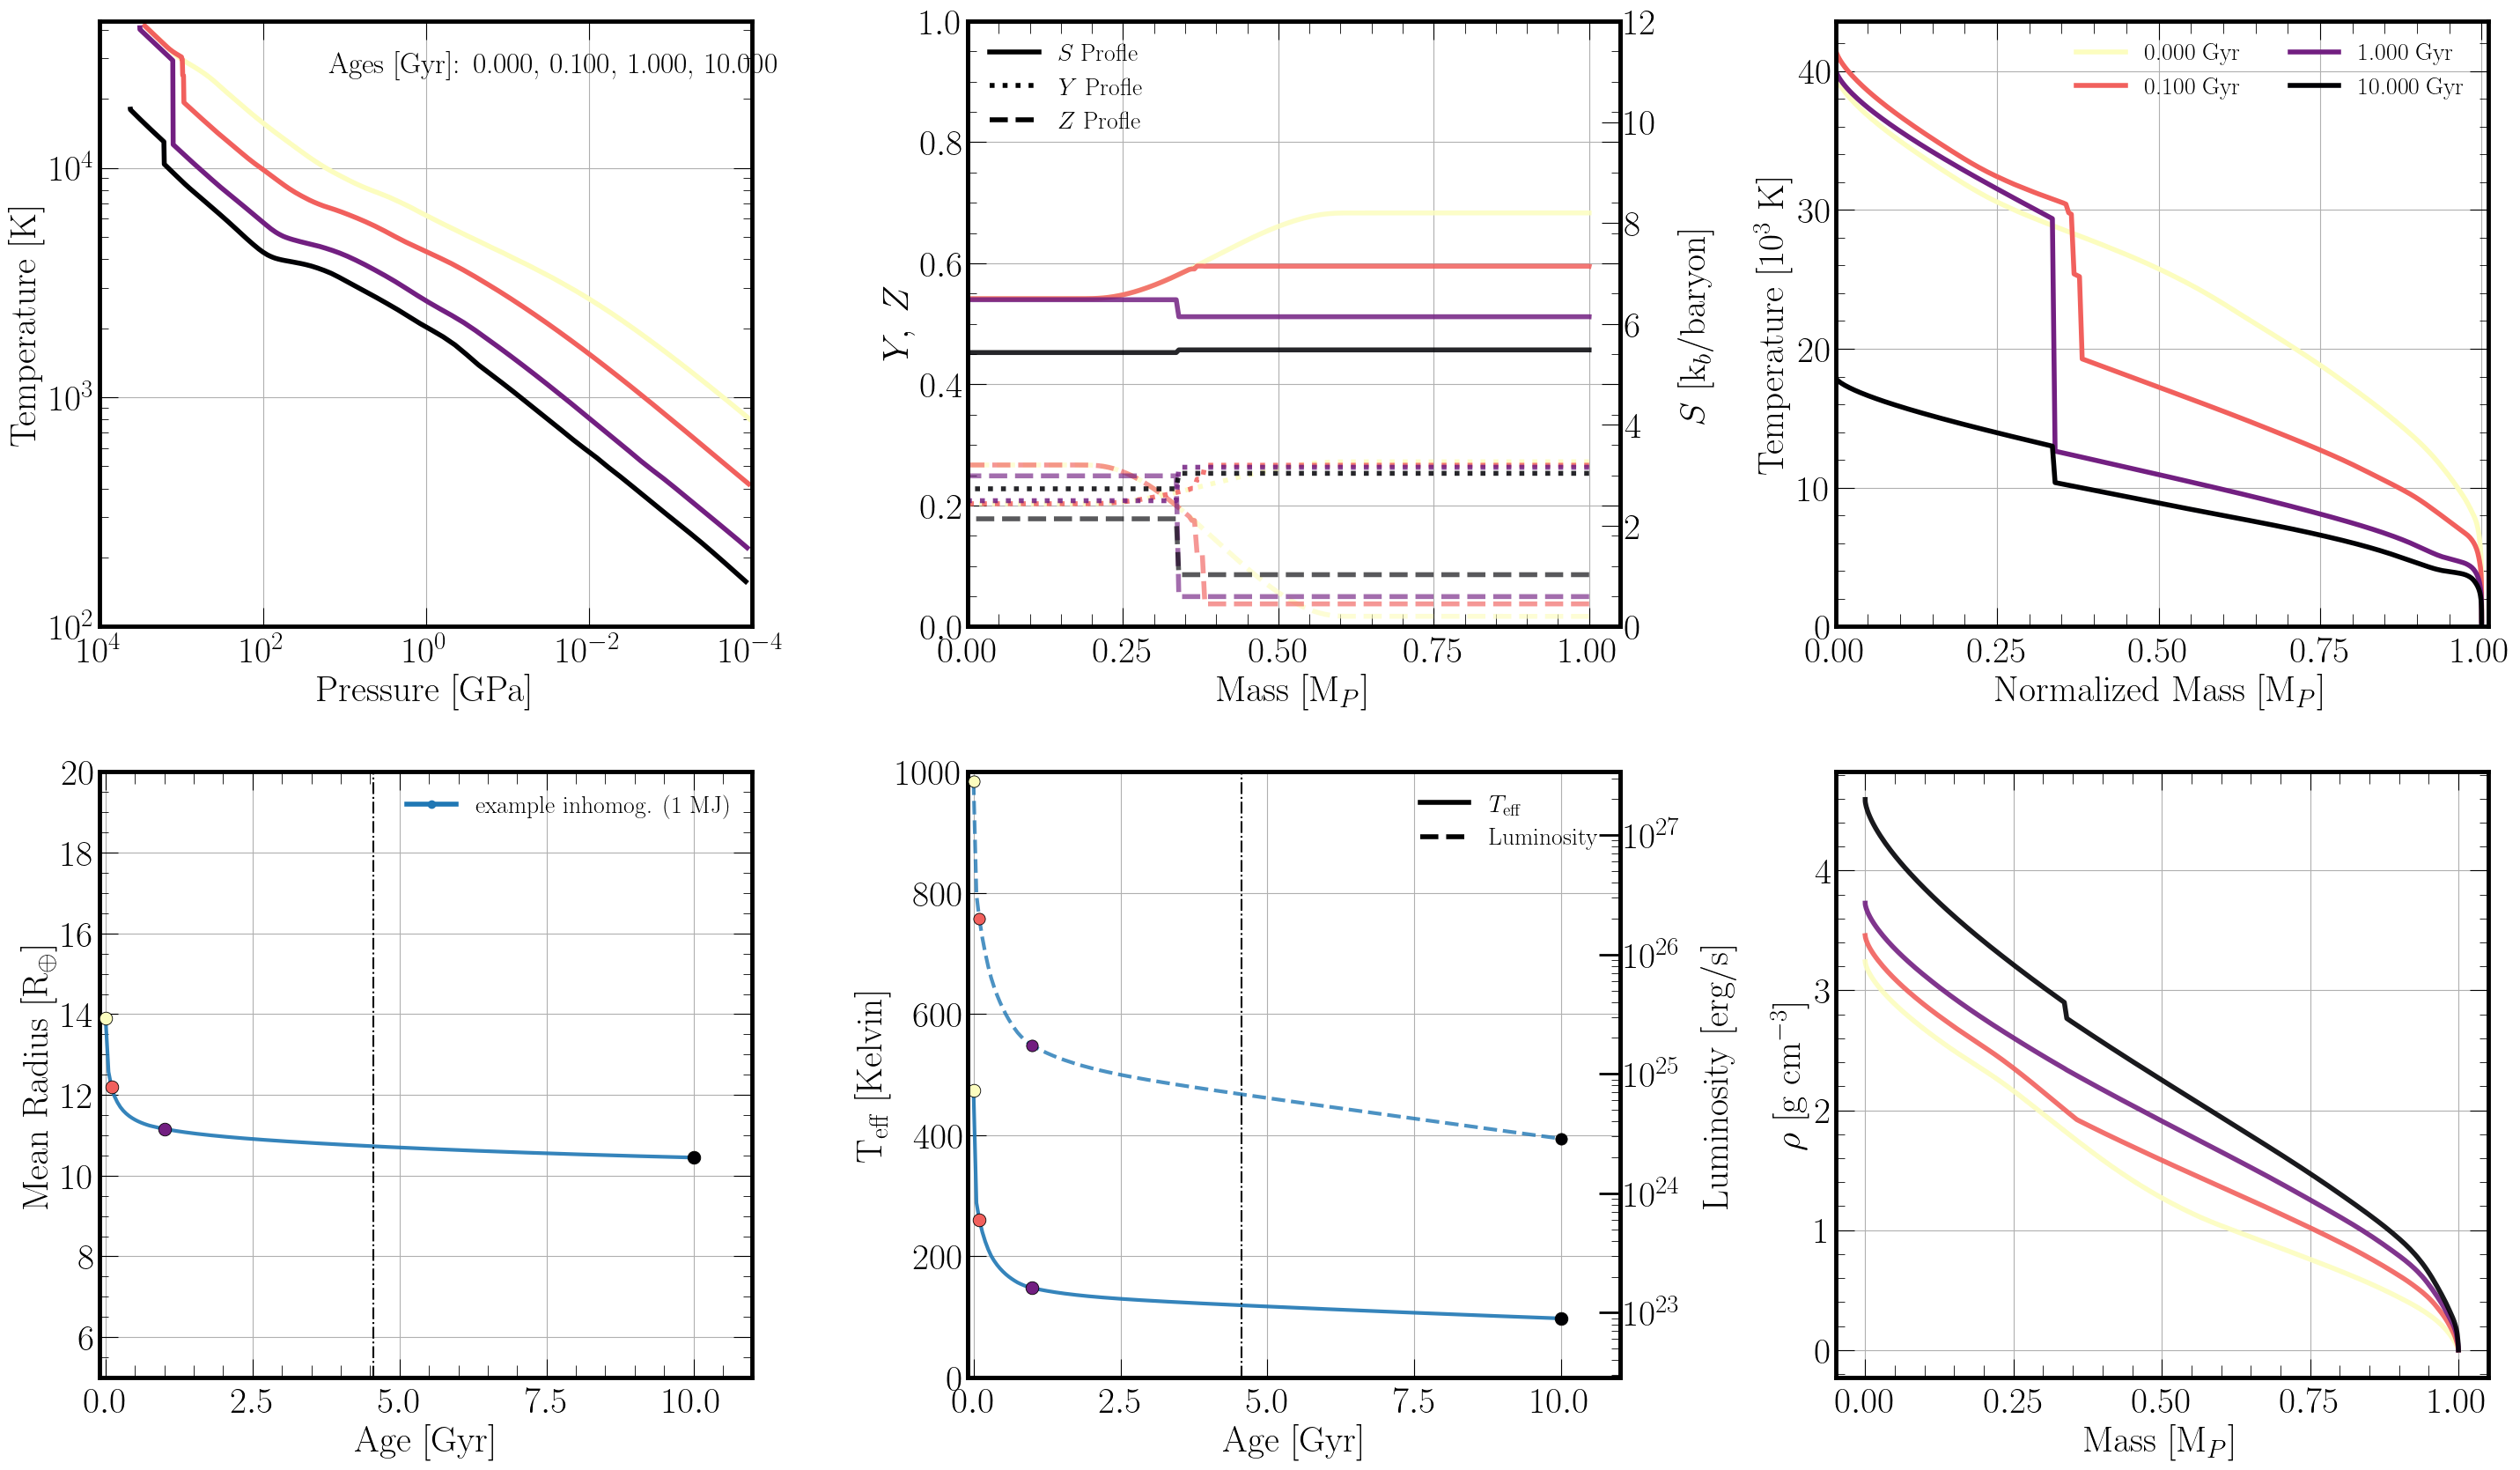

In [8]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_inhomog_struct_example1.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example inhomog. (1 MJ)',
]

init.age_plot(
    ages=[0, 0.1, 1.0, 10.0], # input ages to plot (in Gyr)
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
)

Much of the outer envelope (M$_P > 0.4$) has been homogenized, and interior regions are beginning to mix also. 

## A values-mode model in action: Saturn

The shipped Saturn example [`parameter_examples/parameter_user_saturn_inhomog_struct_example1.ini`](../parameter_examples/parameter_user_saturn_inhomog_struct_example1.ini) is built entirely in values mode, six knots transcribing a smooth, extended compositional gradient, with `struct_interp = pchip` and gaussian smoothing on top:

```
S_ini = 7.9
Z_ini = 0.04

s_init_coords = [0,    0.2,   0.3,  0.5,  0.65, 1.0]
z_init_coords = [0,    0.2,   0.3,  0.5,  0.65, 1.0]
z_init_values = [0.86, 0.51, 0.19, 0.09, 0.04, 0.04]
s_init_values = [2.68,  4.54,  6.32,  6.9,  7.4, 7.9]

struct_interp = pchip
struct_smooth = True
struct_sigma = 2.0
```

Notice how much closer this sits to "digitizing a figure" than the deltas example. You could lift these numbers straight off a published Saturn interior model. Let's look at how this initial condition evolves (this model also appears in `tutorial_solarsystem_planets.ipynb` with more physics discussion; here we're just admiring the profile machinery):

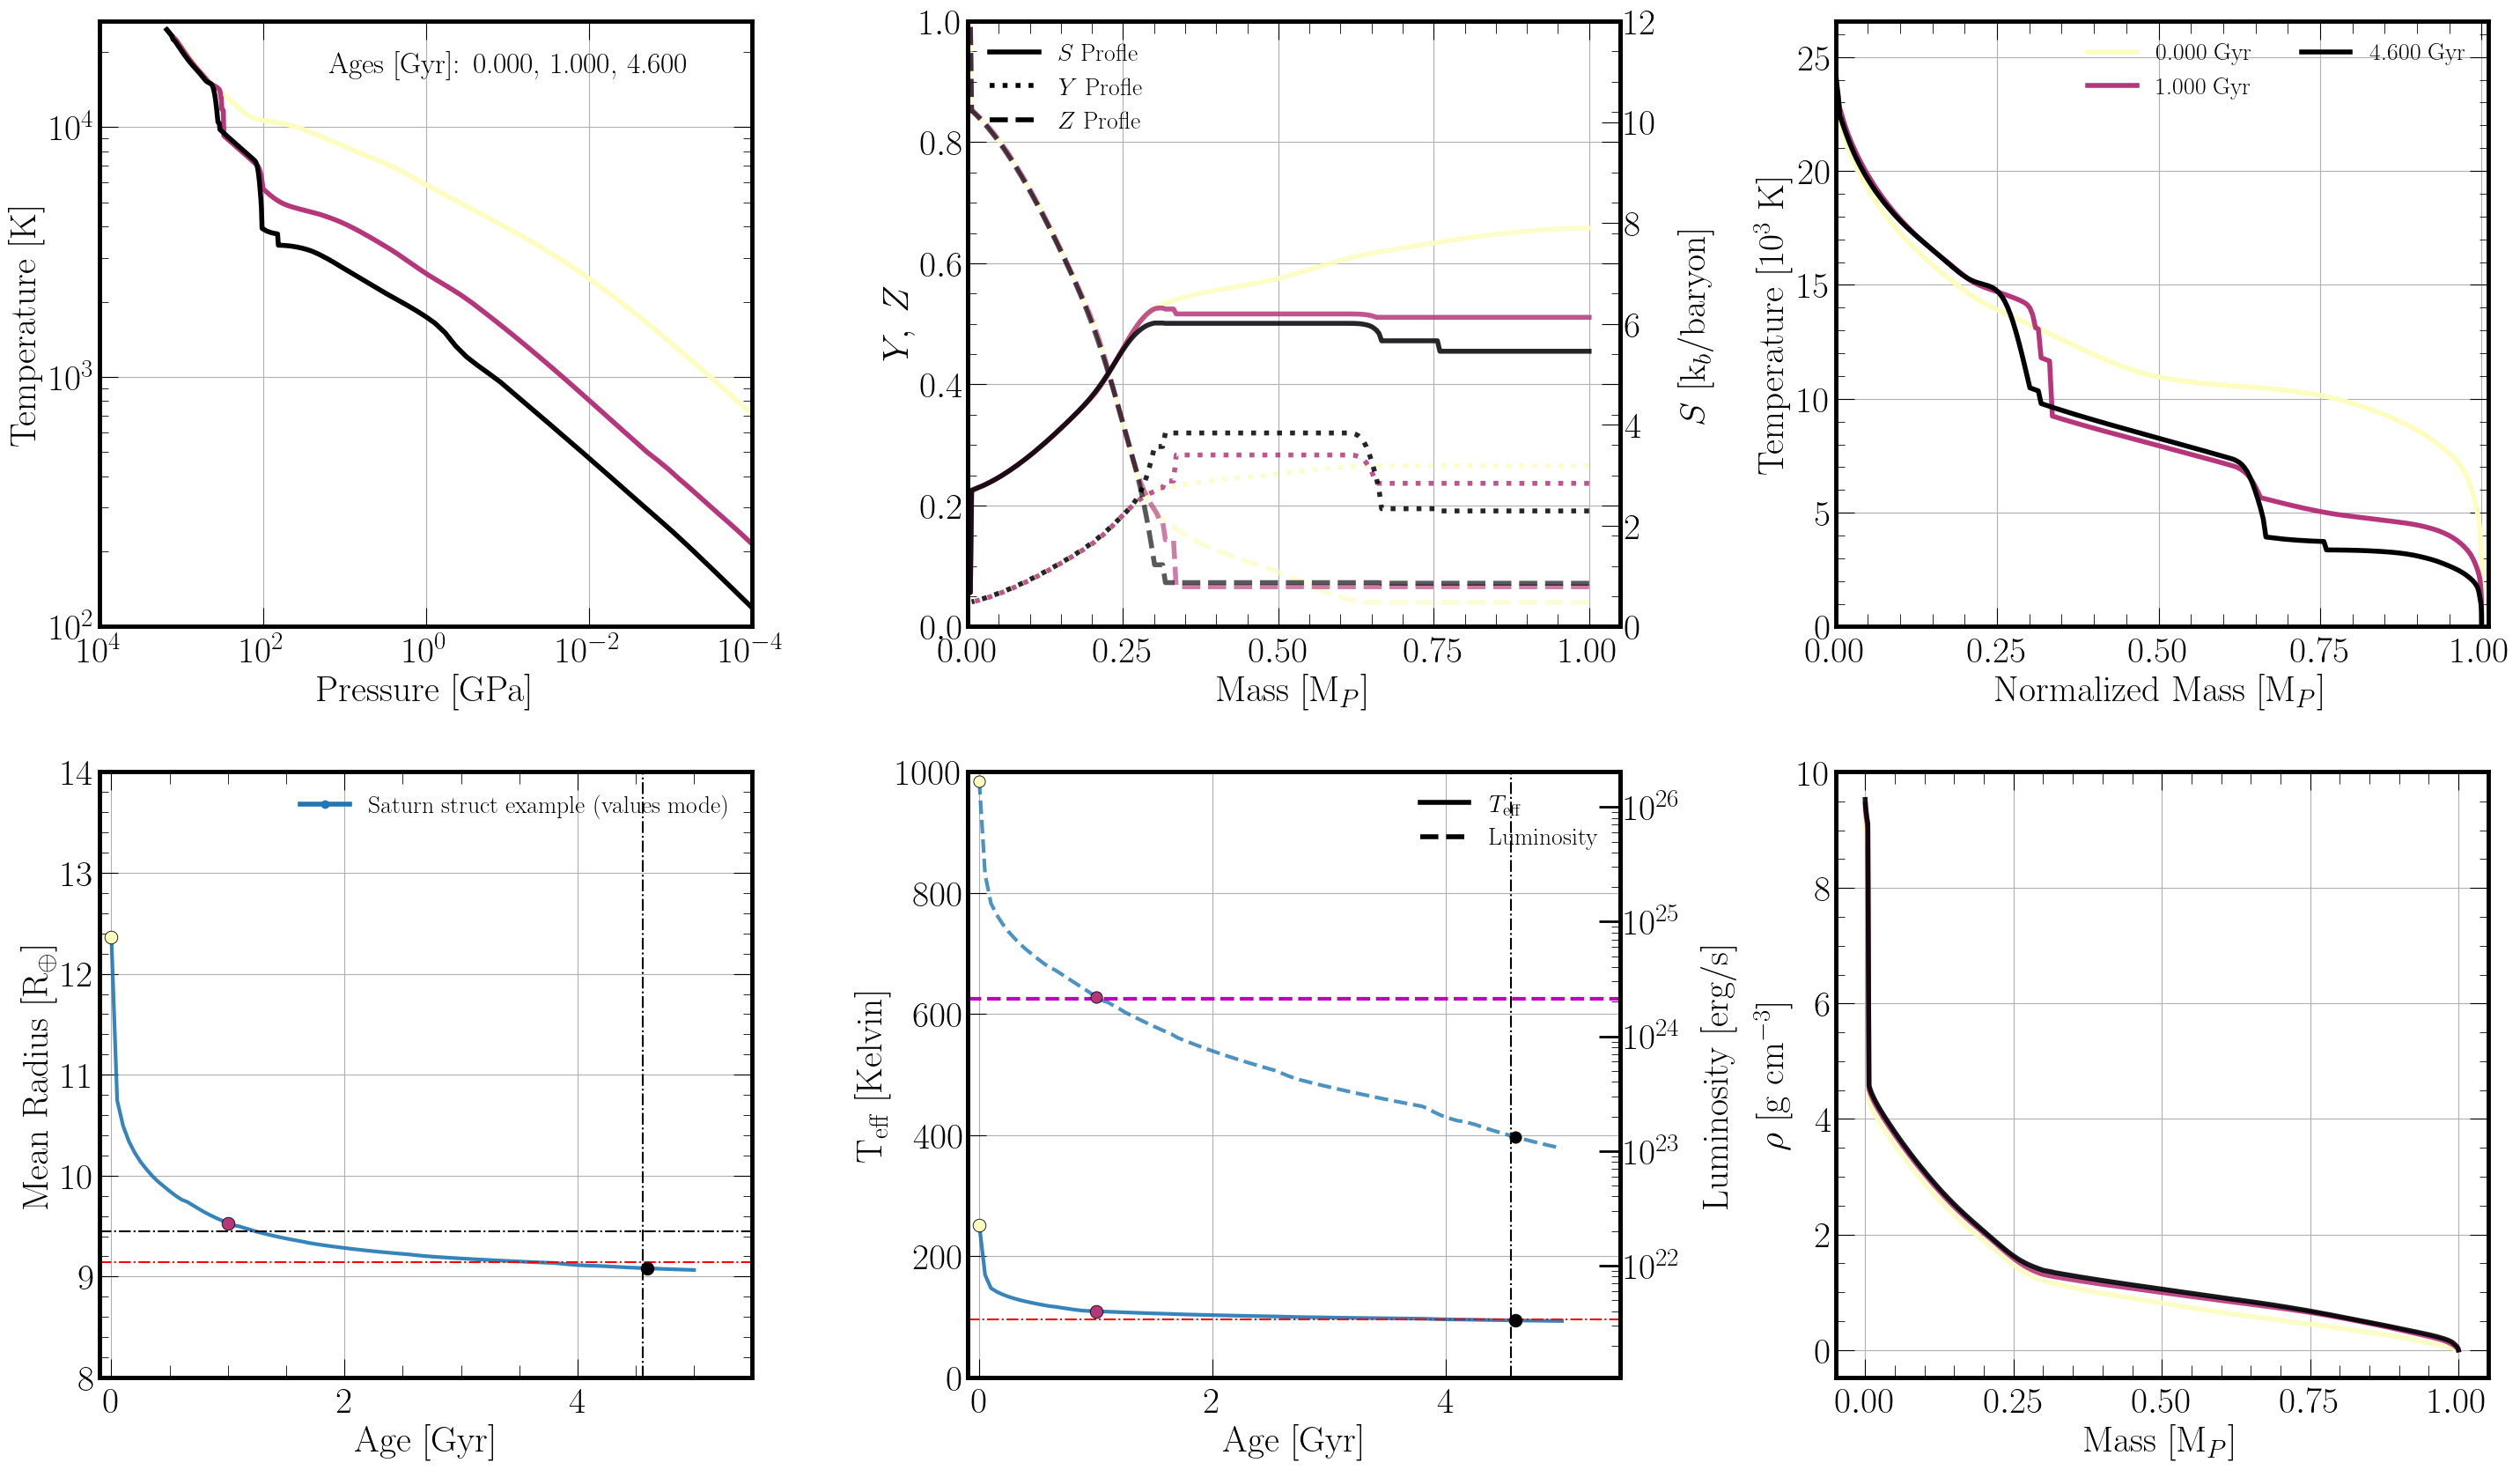

In [9]:
import plot_class

paths = [
    'parameter_examples/parameter_user_saturn_inhomog_struct_example1.ini',
]

init = plot_class.init_plot(paths = paths)

labels = [
    r'Saturn struct example (values mode)',
]

init.age_plot(
    ages=[0, 1.0, 4.6],
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
)

# `gaussian` profiles

`ORCHARD` has functional form options to build continuous profiles. One such option, and one we've used before in Tejada Arevalo et al. (2025) and Sur et al. (2025), is the `gaussian` profile. The `gaussian` profile is a half gaussian function for the $Z$ profile and an inverted gaussian function for the $S$ profile. It's controlled by a center, or mean, called `init_gauss_center`, which is the location of the maximum $Z$ value and minimum $S$ value. The maximum $Z$ value is set by `maximum_init_z`, and the minimum $S$ value is set by `minimum_init_s`. The widths of the two bumps are controlled separately by `init_gauss_stdev_z` and `init_gauss_stdev_s` (in normalized mass units). There is no requirement that the $S$ and $Z$ profiles share a width, though keeping them comparable is the physically sensible starting point. 

**WARNING**: These models can take several hours on a personal computer. Feel free to lower the spatial resolution to run this particular model a bit faster.

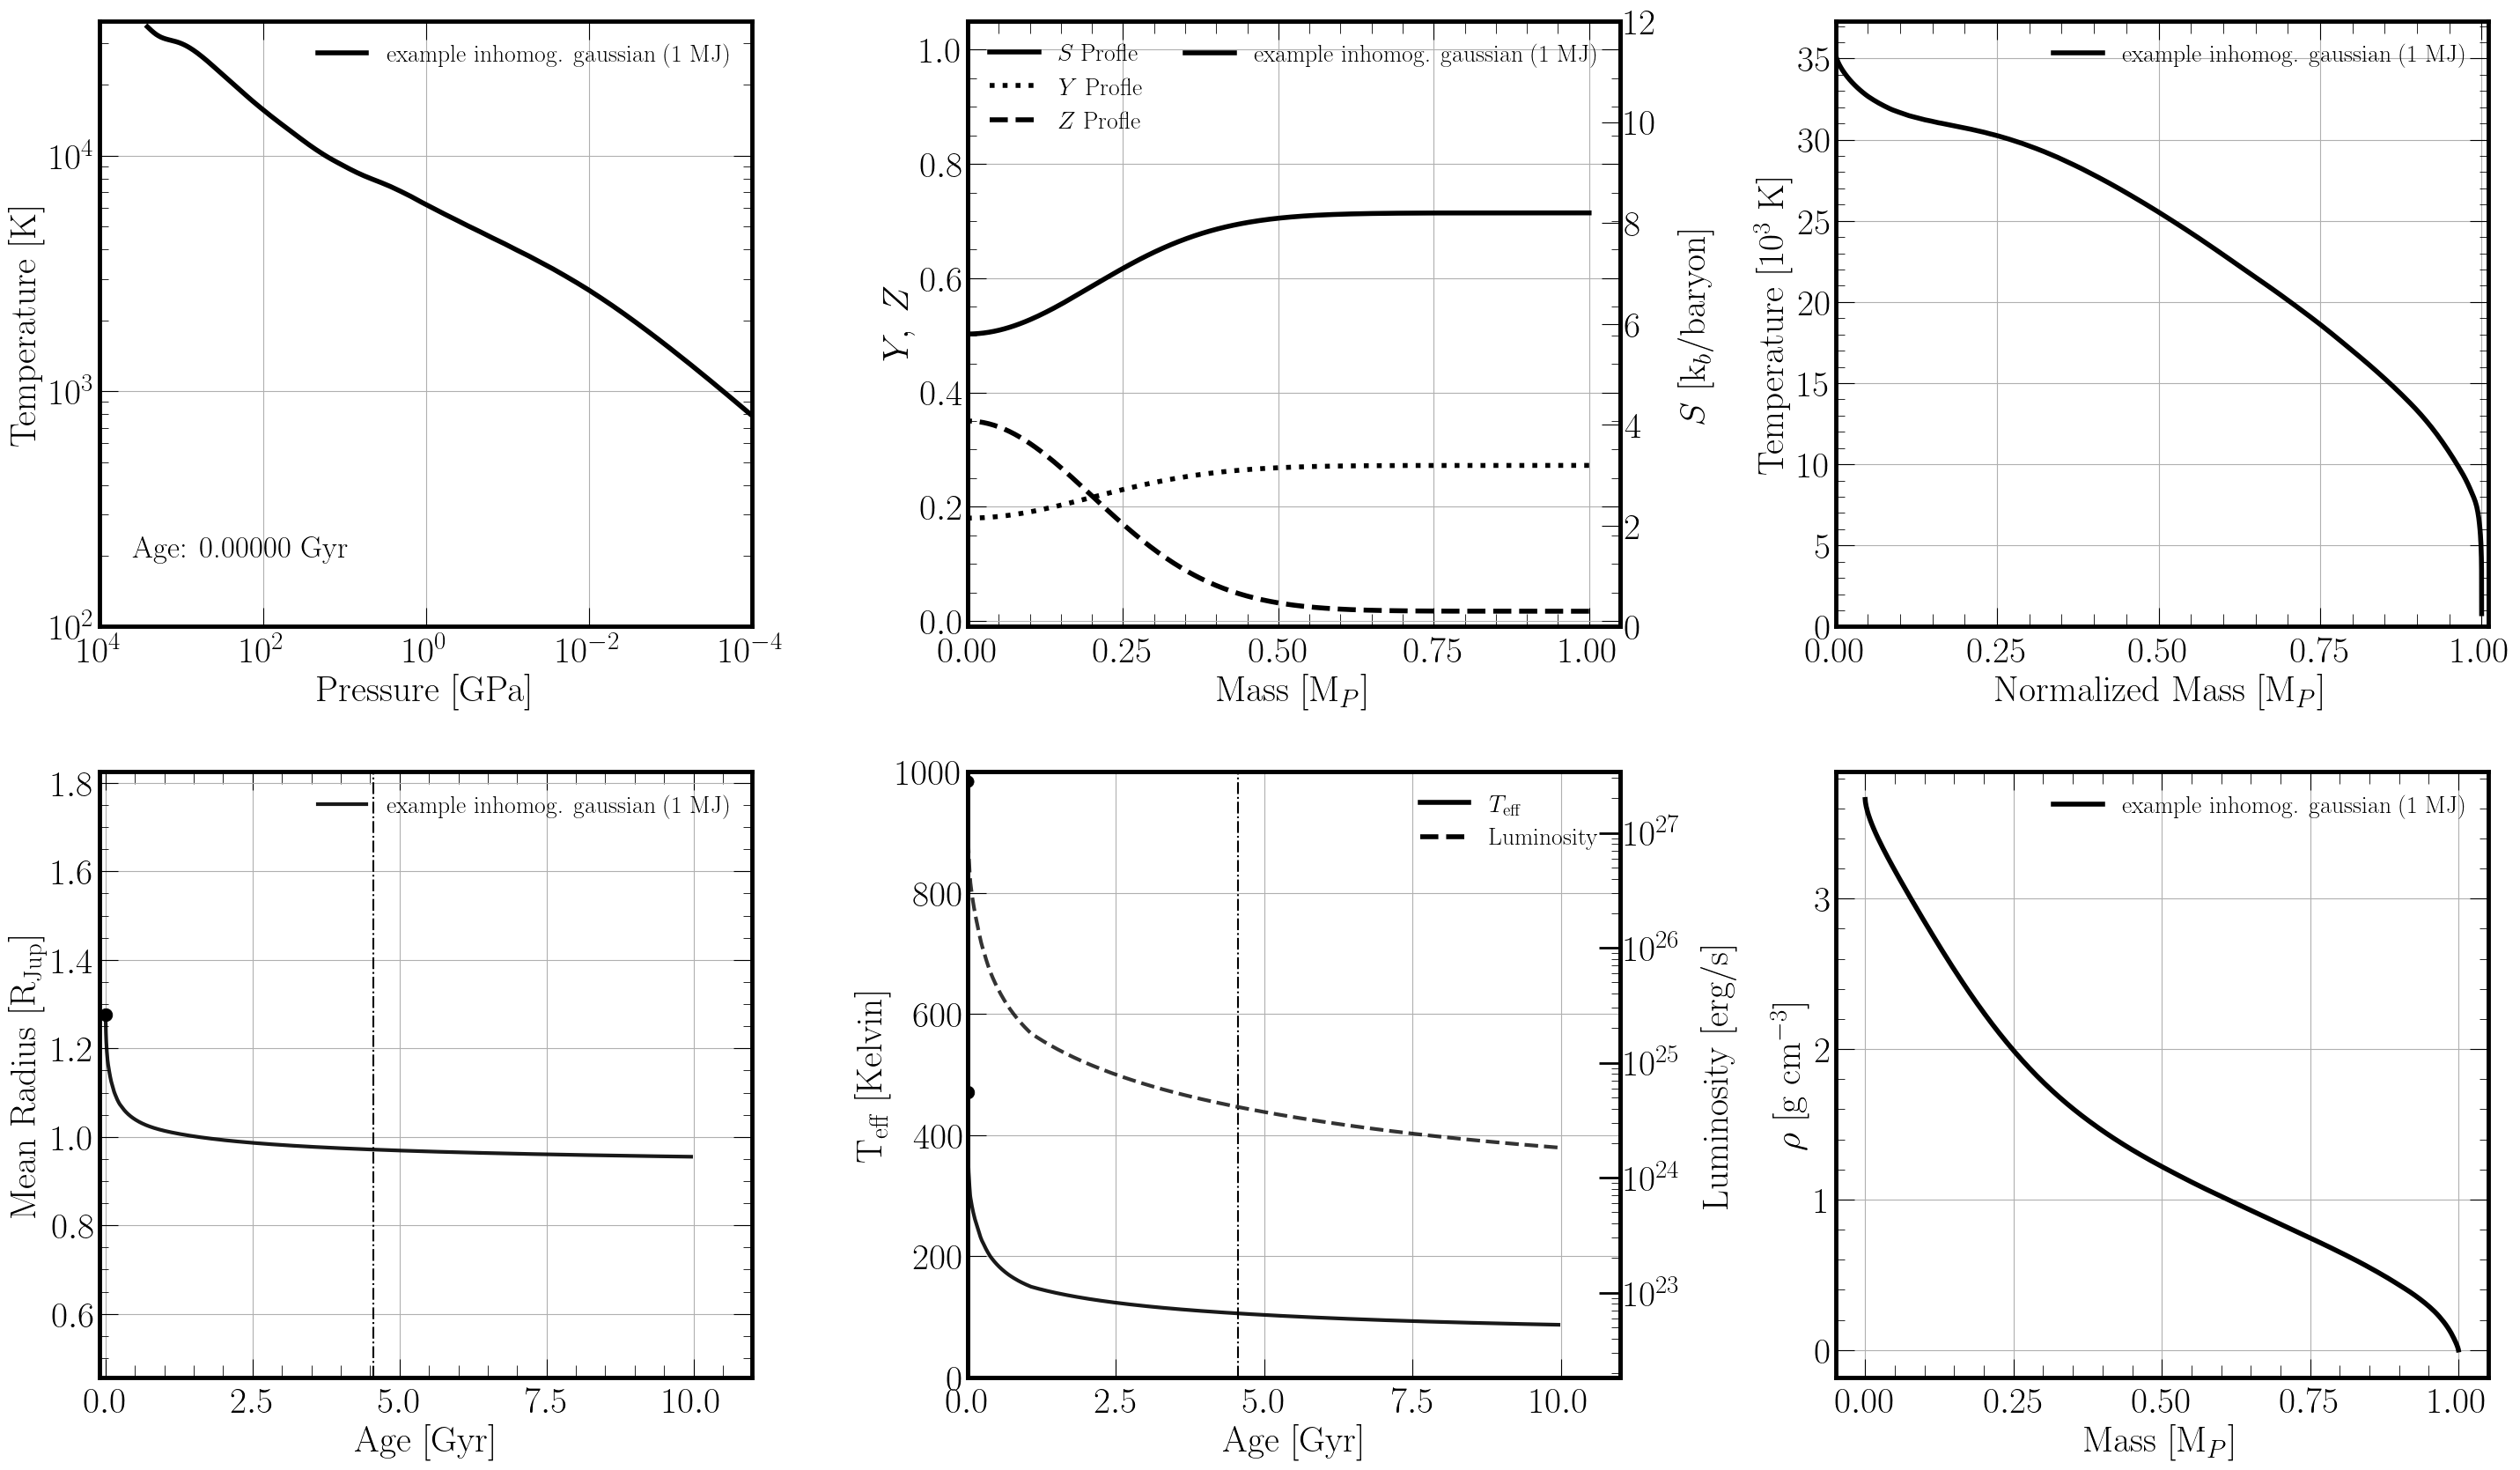

In [10]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_inhomog_gaussian_example1.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example inhomog. gaussian (1 MJ)',
]

init.still_plot(0, # input time to plot profiles (in Gyr)
                'test',
                labels=labels,
                leg_size=20, # optional legend font size,
                panel_num=6,
        )

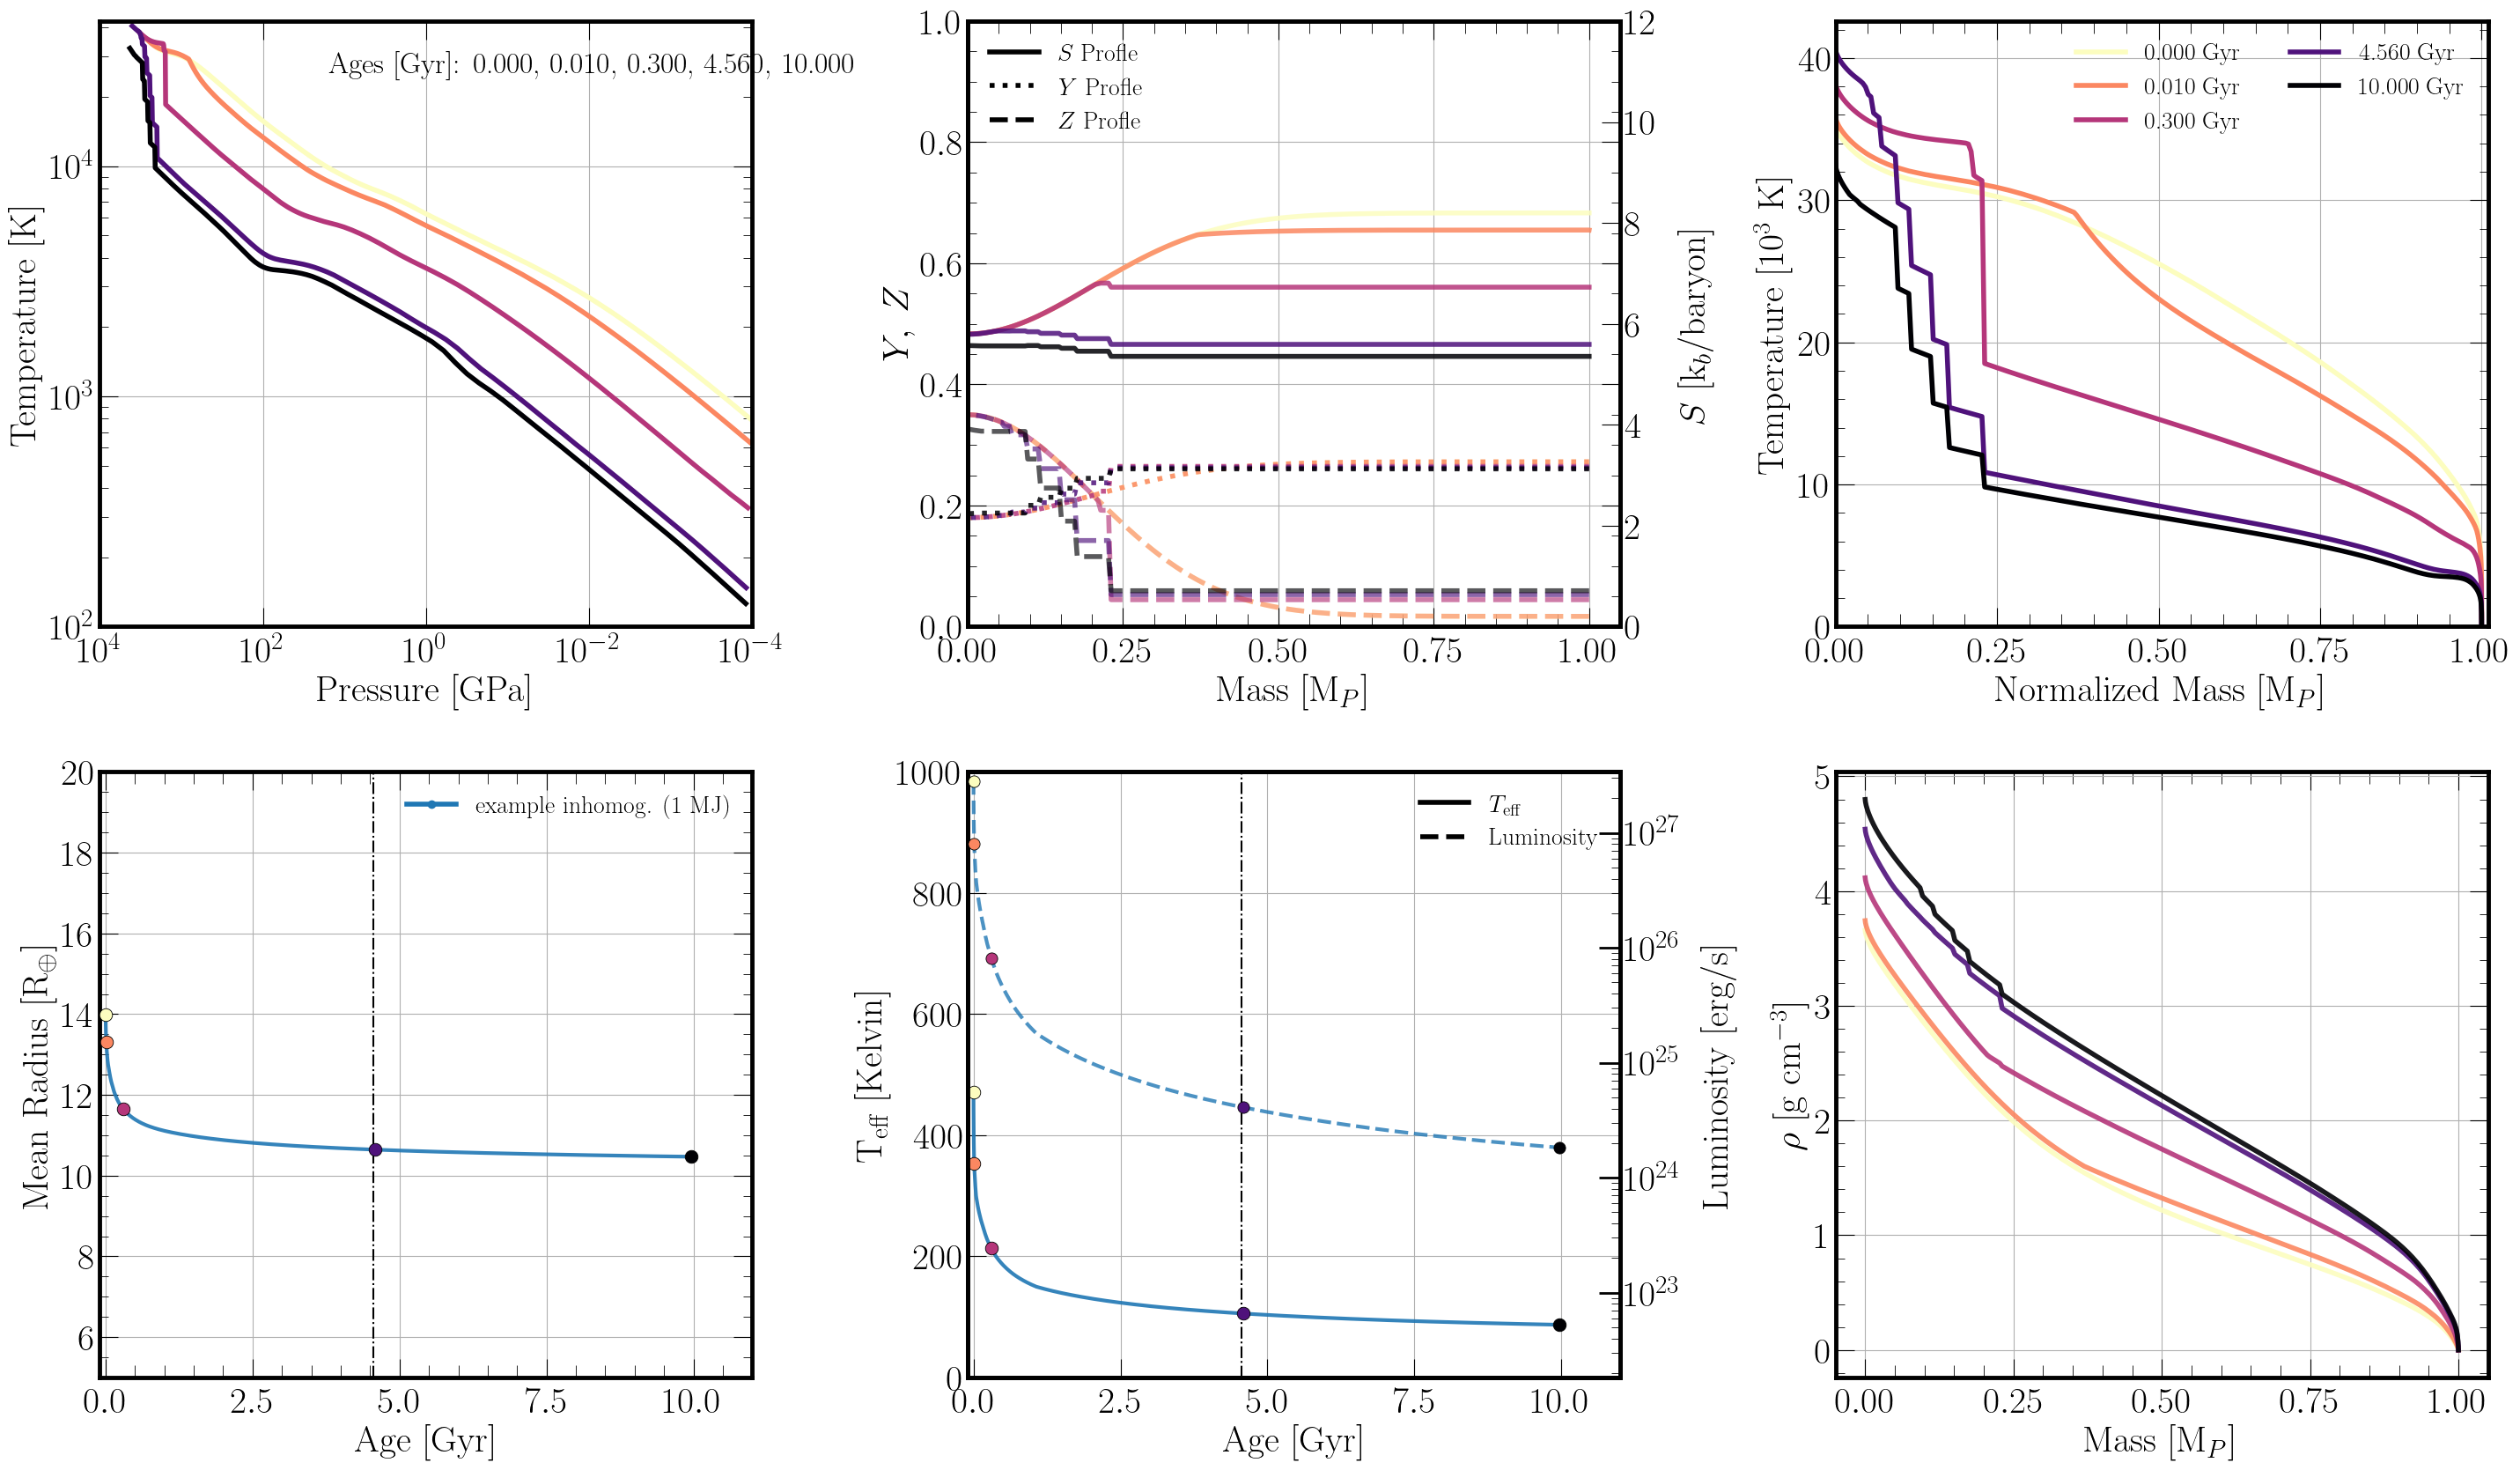

In [11]:
import plot_class

paths = [
    'parameter_examples/parameter_user_jup_inhomog_gaussian_example1.ini',
]

init = plot_class.init_plot(paths = paths)

# specify legend labels for each model (in order of paths list)
labels = [
    r'example inhomog. (1 MJ)',
]

init.age_plot(
    ages=[0, 0.01, 0.3, 4.56, 10.0],
    output_file='age_compare',
    labels=labels,
    save=False,
    leg_size=20,
)

Other functional form profile types are `exponential` and `sigmoid`. Each of these have their own parameters to set up. However, these profiles can be promptly replicated using `struct` profile combinations with gaussian smoothing, so we omit them here for brevity.